In [1]:
#bar或line图以及线性趋势和多项式拟合
def Autobar_or_line(v,times,timename,iflat,latname,lat,iflon,lonname,lon,iflevel,levelname,levels,line_or_bar,vs=None,ifself_vmax_vmin='no',selfvmax=None,selfvmin=None,linenum=1,xlabelname='x',ylabelname='y',bar_line_title='',label='y',linewidth=4,selfcolor='k',selflinestyle='-',iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=1,labelsize=20,xlabelformat='month',valuemodel='+',bar_text='no'):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    import xarray as xr
    import math
    from matplotlib.pyplot import MultipleLocator
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error,r2_score
    from sklearn.model_selection import train_test_split
    from scipy import signal
    import lanczos
    import matplotlib as mpl
    from scipy.stats import gaussian_kde
    from matplotlib.colors import to_rgb
    from matplotlib.colors import LinearSegmentedColormap
    
    plt.rcParams['font.sans-serif']=['SimHei'] #正常显示中文
    plt.rcParams['axes.unicode_minus']=False #正常显示正负号
    mpl.rc('axes',lw=2)
    ym = []
    yf = []
    regressline = []
    yd = []
    if selfcolor is not None and isinstance(selfcolor, str):
        try:
            selfshadedcolor = getattr(plt.cm, selfcolor)
        except AttributeError:
            selfshadedcolor = plt.cm.viridis
    elif selfcolor is None:
         selfshadedcolor = plt.cm.viridis
    else:
        selfshadedcolor = LinearSegmentedColormap.from_list("custom_cmap", selfcolor, N=len(v))
    if iflat!='no':
        lat = np.array(lat)
    if iflon !='no':
        lon = np.array(lon)
    if iflevel !='no' and iflevel !='yes':
        levels = np.array(levels)
    v = np.array(v)
    times = np.array(times)
    if line_or_bar != 'onlydata' and line_or_bar !='scatter':
        fig = plt.figure(figsize = (12,8),facecolor='white')
        ax = fig.add_subplot(111)
        x_major_locator=MultipleLocator(xspace)
        ax.xaxis.set_major_locator(x_major_locator)
        if valuemodel =='+' or valuemodel =='-':
            if ifself_vmax_vmin=='yes':
                ax.set_ylim(selfvmin,selfvmax)
            else:
                if np.nanmax(v)>=0.1 or np.nanmin(v)<=-0.1:
                    ax.set_ylim(math.floor(np.nanmin(v)),math.ceil(np.nanmax(v)))
                else:
                    ax.set_ylim(np.nanmin(v),np.nanmax(v))
        elif valuemodel == '+-' or valuemodel =='-+':
            if ifself_vmax_vmin=='yes':
                ax.set_ylim(selfvmin,selfvmax)
            else:
                if np.nanmax(v)>=0.1 or np.nanmin(v)<=-0.1:
                    if np.abs(np.nanmin(v))> np.abs(np.nanmax(v)):
                        ax.set_ylim(math.floor(np.nanmin(v)),math.ceil(-np.nanmin(v)))
                    else:
                        ax.set_ylim(math.floor(-np.nanmax(v)),math.ceil(np.nanmax(v)))
                else:
                    if np.abs(np.nanmin(v))> np.abs(np.nanmax(v)):
                        ax.set_ylim(np.nanmin(v),-np.nanmin(v))
                    else:
                        ax.set_ylim(-np.nanmax(v),np.nanmax(v))
        time1 = []
        for i in range(len(times)):
            if xlabelformat =='year':
                time1.append(pd.to_datetime(str(np.array(times[i]))).strftime('%Y'))
            elif xlabelformat =='month':
                time1.append(pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m'))
            elif xlabelformat == 'day':
                time1.append(pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d'))
            elif xlabelformat == 'hour':
                time1.append(pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H'))
            else:
                time1.append(times[i])
        if linenum == 1:
            color = []
            if (line_or_bar) == 'bar' and (selfcolor != None):
                b1 = ax.bar(time1,v,color = selfcolor,label = label)
            elif (line_or_bar) == 'bar' and (selfcolor==None):
                for i in range (0,len(v)):
                    if (v[i] >= 0):
                        color.append('red')
                    elif (v[i] <= 0):
                        color.append('blue')
                b1 = ax.bar(time1,v,color = color,label = label)
            elif line_or_bar == 'line':
                l1 = ax.plot(time1,v,selfcolor,linestyle=selflinestyle,linewidth = linewidth,label = label)
            elif line_or_bar == 'lineandbar':
                for i in range(0,len(v)):
                    if (v[i] >= 0):
                        color.append('red')
                    elif (v[i] <0):
                        color.append('blue')
                b1 = ax.bar(time1,v,color = color,label = label)
                l1 = ax.plot(time1,v,selfcolor,linestyle=selflinestyle,linewidth = linewidth,label = label)
        else:
            if line_or_bar=='line':
                for i in range(v.shape[0]):
                    if line_or_bar == 'line':
                        l1 = ax.plot(time1,v[i],selfcolor[i],linestyle=selflinestyle[i],linewidth = linewidth,label = label[i])
            elif line_or_bar=='bar':
                bar_width = 0.8 / v.shape[1]
                x=np.arange(np.array(v).shape[0])
                for i in range(np.array(v[0]).shape[0]):
                    offset=(i - (v.shape[1] - 1) / 2) * bar_width
                    y=[vs[i] for vs in v]
                    b1=ax.bar(x+offset,y,width=bar_width,label=label[i],color=selfcolor[i])
                plt.xticks(x,time1)
        if bar_text=='yes':
            if np.nanmin(v)>=1:
                ax.bar_label(b1, fmt='%.0f', padding=3, color='k', fontsize=labelsize,fontweight='bold')
            elif np.nanmin(v)>=0.1:
                ax.bar_label(b1, fmt='%.1f', padding=3, color='k', fontsize=labelsize,fontweight='bold')
            elif np.nanmin(v)>=0.01:
                ax.bar_label(b1, fmt='%.2f', padding=3, color='k', fontsize=labelsize,fontweight='bold')
            else:
                ax.bar_label(b1, fmt='%.3f', padding=3, color='k', fontsize=labelsize,fontweight='bold')
    elif line_or_bar == 'scatter':
        fig = plt.figure(figsize = (12,8),facecolor='white')
        ax = fig.add_subplot(111)
        xy = np.vstack([v, vs])
        density = gaussian_kde(xy)(xy)
        if valuemodel =='+' or valuemodel =='-':
            if ifself_vmax_vmin=='yes':
                ax.set_ylim(selfvmin[1],selfvmax[1])
                ax.set_xlim(selfvmin[0],selfvmax[0])
            else:
                ax.set_xlim(np.nanmin(v)-(np.nanmax(v)-np.nanmin(v))*0.1,np.nanmax(v)+(np.nanmax(v)-np.nanmin(v))*0.1)
                ax.set_ylim(np.nanmin(vs)-(np.nanmax(vs)-np.nanmin(vs))*0.1,np.nanmax(vs)+(np.nanmax(vs)-np.nanmin(vs))*0.1)
        elif valuemodel == '+-' or valuemodel =='-+':
            if ifself_vmax_vmin=='yes':
                if np.abs(selfvmin[1])>np.abs(selfvmax[1]):
                    ax.set_ylim(selfvmin[1]+selfvmin[1]*0.1,-selfvmin[1]-selfvmin[1]*0.1)
                else:
                    ax.set_ylim(-selfvmax[1]-selfvmax[1]*0.1,selfvmax[1]+selfvmax[1]*0.1)
                if np.abs(selfvmin[0])>np.abs(selfvmax[0]):
                    ax.set_xlim(selfvmin[0]+selfvmin[0]*0.1,-selfvmin[0]-selfvmin[0]*0.1)
                else:
                    ax.set_xlim(-selfvmax[0]-selfvmax[0]*0.1,selfvmax[0]+selfvmax[0]*0.1)
            else:
                if np.abs(np.nanmin(v))> np.abs(np.nanmax(v)):
                    ax.set_xlim(np.nanmin(v)+np.nanmin(v)*0.1,-np.nanmin(v)-np.nanmin(v)*0.1)
                else:
                    ax.set_xlim(-np.nanmax(v)-np.nanmax(v)*0.1,np.nanmax(v)+np.nanmax(v)*0.1)
                if np.abs(np.nanmin(vs))> np.abs(np.nanmax(vs)):
                    ax.set_ylim(np.nanmin(vs)+np.nanmin(vs)*0.1,-np.nanmin(vs)-np.nanmin(vs)*0.1)
                else:
                    ax.set_ylim(-np.nanmax(vs)-np.nanmax(vs)*0.1,np.nanmax(vs)+np.nanmax(vs)*0.1)
        s1 = ax.scatter(v, vs, c=density, cmap=selfshadedcolor)
        cb=fig.colorbar(s1,orientation='horizontal',pad = 0.10+labelsize*0.002,fraction = 0.05,aspect = 22,format='%.3f')
        cb.ax.tick_params(length=0,width=0,labelsize=labelsize)
        ticks = np.linspace(np.nanmin(density), np.nanmax(density), 5)
        cb.set_ticks(ticks)
    else:
        time1=times
    if (iftend == 'yes' and linenum == 1) or (iftend == 'yes' and line_or_bar == 'scatter'):
        solver = LinearRegression(fit_intercept=True, copy_X=True,n_jobs=-1)
        if line_or_bar != 'scatter':
            time2 = np.arange(0,len(times))
            time2=time2[np.logical_not(np.isnan(v))]
            v=v[np.logical_not(np.isnan(v))]
            time2 = time2.reshape(-1,1)
            model = solver.fit(time2,v)
            regressline = solver.predict(time2)
            regressline = np.array(regressline)
        else:
            v = np.array(v)
            vs=vs[np.logical_not(np.isnan(v))]
            v=v[np.logical_not(np.isnan(v))]
            v=v[np.logical_not(np.isnan(vs))]
            vs=vs[np.logical_not(np.isnan(vs))]
            v = v.reshape(-1,1)
            model = solver.fit(v,vs)
            regressline = solver.predict(v)
            regressline = np.array(regressline)
        if line_or_bar != 'onlydata':
            if line_or_bar != 'scatter':
                l2 = ax.plot(time2,regressline,'r-',linewidth = linewidth,label = '趋势线')
            else:
                l2 = ax.plot(v,regressline,'r-',linewidth = linewidth,label = '趋势线')
                if ifself_vmax_vmin=='yes':
                    x = np.linspace(min(selfvmin[0], selfvmin[1])*10, max(selfvmax[0], selfvmax[1])*10, 100)
                else:
                    x = np.linspace(min(v.min(), vs.min())*10, max(v.max(), vs.max())*10, 100)
                ax.plot(x, x, 'k-',linewidth = linewidth)
    elif iftend =='yes' and linenum>1:
        regressline=[]
        for i in range(v.shape[0]):
            solver = LinearRegression(fit_intercept=True, copy_X=True,n_jobs=-1)
            time2 = np.arange(0,len(times))
            time2=time2[np.logical_not(np.isnan(v[i,:]))]
            v_copy=v[i,np.logical_not(np.isnan(v[i,:]))]
            time2 = time2.reshape(-1,1)
            model = solver.fit(time2,v_copy)
            regressline.append(np.array(solver.predict(time2)))
            l2 = ax.plot(time2,regressline[i],color=selfcolor[i],linestyle='--',    linewidth = linewidth)
    elif iftend == 'area':
        solver = LinearRegression(fit_intercept=True, copy_X=True,n_jobs=-1)
        time2 = np.arange(0,len(times)).reshape(-1,1)
        if iflevel =='yes' or iflevel =='no':
            if iflat !='no':
                if iflon !='no':
                    regressline = np.zeros((v.shape[1],v.shape[2]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]): 
                            time2 = time3
                            v1 = v[:,i,j]
                            time2=time2[np.logical_not(np.isnan(v1))]
                            v1=v1[np.logical_not(np.isnan(v1))]
                            if len(time2)>=2:
                                model = solver.fit(time2,v1)
                                regresslines = solver.predict(time2)
                                regressline[i,j]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                            else:
                                regressline[i,j]=np.nan
                else:
                    regressline = np.zeros((v.shape[1]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        time2 = time3
                        v1 = v[:,i]
                        time2=time2[np.logical_not(np.isnan(v1))]
                        v1=v1[np.logical_not(np.isnan(v1))]
                        if len(time2)>=2:
                            model = solver.fit(time2,v1)
                            regresslines = solver.predict(time2)
                            regressline[i]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                        else:
                            regressline[i]=np.nan
            else:
                if iflon !='no':
                    regressline = np.zeros((v.shape[1]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        time2 = time3
                        v1 = v[:,i]
                        time2=time2[np.logical_not(np.isnan(v1))]
                        v1=v1[np.logical_not(np.isnan(v1))]
                        if len(time2)>=2:
                            model = solver.fit(time2,v1)
                            regresslines = solver.predict(time2)
                            regressline[i]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                        else:
                            regressline[i]=np.nan
                else:
                    print("请使用参数iftend == 'yes'")
        else:
            if iflat !='no':
                if iflon !='no':
                    regressline = np.zeros((v.shape[1],v.shape[2],v.shape[3]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]): 
                            for k in range(v.shape[3]):
                                time2 = time3
                                v1 = v[:,i,j,k]
                                time2=time2[np.logical_not(np.isnan(v1))]
                                v1=v1[np.logical_not(np.isnan(v1))]
                                if len(time2)>=2:
                                    model = solver.fit(time2,v1)
                                    regresslines = solver.predict(time2)
                                    regressline[i,j,k]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                                else:
                                    regressline[i,j,k]=np.nan
                else:
                    regressline = np.zeros((v.shape[1],v.shape[2]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]): 
                            time2 = time3
                            v1 = v[:,i,j]
                            time2=time2[np.logical_not(np.isnan(v1))]
                            v1=v1[np.logical_not(np.isnan(v1))]
                            if len(time2)>=2:
                                model = solver.fit(time2,v1)
                                regresslines = solver.predict(time2)
                                regressline[i,j]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                            else:
                                regressline[i,j]=np.nan
            else:
                if iflon !='no':
                    regressline = np.zeros((v.shape[1],v.shape[2]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]): 
                            time2 = time3
                            v1 = v[:,i,j]
                            time2=time2[np.logical_not(np.isnan(v1))]
                            v1=v1[np.logical_not(np.isnan(v1))]
                            if len(time2)>=2:
                                model = solver.fit(time2,v1)
                                regresslines = solver.predict(time2)
                                regressline[i,j]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                            else:
                                regressline[i,j]=np.nan
                else:
                    regressline = np.zeros((v.shape[1]))
                    time3 = time2
                    for i in range(v.shape[1]):
                        time2 = time3
                        v1 = v[:,i]
                        time2=time2[np.logical_not(np.isnan(v1))]
                        v1=v1[np.logical_not(np.isnan(v1))]
                        if len(time2)>=2:
                            model = solver.fit(time2,v1)
                            regresslines = solver.predict(time2)
                            regressline[i]=(regresslines[1]-regresslines[0])/(time2[1]-time2[0])
                        else:
                            regressline[i]=np.nan
        if iflevel =='yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    regressline = xr.DataArray(regressline,[(latname,lat),(lonname,lon)])
                else:
                    regressline = xr.DataArray(regressline,[(latname,lat),])
            else:
                if iflon!='no':
                    regressline = xr.DataArray(regressline,[(lonname,lon)])
                else:
                    print("请使用参数iftend == 'yes'")
                    regressline = None
        else:
            if iflat !='no':
                if iflon !='no':
                    regressline = xr.DataArray(regressline,[(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    regressline = xr.DataArray(regressline,[(levelname,levels),(latname,lat),])
            else:
                if iflon!='no':
                    regressline = xr.DataArray(regressline,[(levelname,levels),(lonname,lon)])
                else:
                    regressline = xr.DataArray(regressline,[(levelname,levels)])
    if ifmultitend == 'yes' and linenum == 1:
        X = np.arange(0,len(times)).reshape(-1,1)
        y = v
        if not(np.isnan(y).any()):
            x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
            rmses = []
            degrees = np.arange(1, 10)
            min_rmse, min_deg,score = 1e10, 0 ,0

            for deg in degrees:
                # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                poly = PolynomialFeatures(degree=deg, include_bias=False)
                x_train_poly = poly.fit_transform(x_train)

                # 多项式拟合
                poly_reg = LinearRegression()
                poly_reg.fit(x_train_poly, y_train)
                #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                # 测试集比较
                x_test_poly = poly.fit_transform(x_test)
                y_test_pred = poly_reg.predict(x_test_poly)

                #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                rmses.append(poly_rmse)
                # r2 范围[0，1]，R2越接近1拟合越好。
                r2score = r2_score(y_test, y_test_pred)

                # degree交叉验证
                if min_rmse > poly_rmse:
                    min_rmse = poly_rmse
                    min_deg = deg
                    score = r2score
            time2 = np.arange(0,len(times))
            ymss = np.polyfit(time2,y,min_deg)
            yms= np.poly1d(ymss)
            ym=yms(time2)
            ym = np.array(ym)
        else:
            ym = np.zeros((v.shape[0]))
            ym[:] = np.nan
        if line_or_bar != 'onlydata':
            l3 = ax.plot(time1,ym,'p-',linewidth = linewidth,label = '多项式拟合')
    elif ifmultitend == 'yes' and linenum > 1:
        ym=[]
        for i in range(v.shape[0]):
            X = np.arange(0,len(times)).reshape(-1,1)
            y = v[i,:]
            if not(np.isnan(y).any()):
                x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                rmses = []
                degrees = np.arange(1, 10)
                min_rmse, min_deg,score = 1e10, 0 ,0
    
                for deg in degrees:
                    # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                    poly = PolynomialFeatures(degree=deg, include_bias=False)
                    x_train_poly = poly.fit_transform(x_train)
    
                    # 多项式拟合
                    poly_reg = LinearRegression()
                    poly_reg.fit(x_train_poly, y_train)
                    #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数
    
                    # 测试集比较
                    x_test_poly = poly.fit_transform(x_test)
                    y_test_pred = poly_reg.predict(x_test_poly)
    
                    #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                    poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                    rmses.append(poly_rmse)
                    # r2 范围[0，1]，R2越接近1拟合越好。
                    r2score = r2_score(y_test, y_test_pred)
    
                    # degree交叉验证
                    if min_rmse > poly_rmse:
                        min_rmse = poly_rmse
                        min_deg = deg
                        score = r2score
                time2 = np.arange(0,len(times))
                ymss = np.polyfit(time2,y,min_deg)
                yms= np.poly1d(ymss)
                ym.append(np.array(yms(time2)))
            else:
                ym.append(np.full(v.shape[0], np.nan))
            if line_or_bar != 'onlydata':
                l3 = ax.plot(time1,ym[i],color=selfcolor[i],linestyle='--',    linewidth = linewidth)
    elif ifmultitend == 'area':
        if iflevel == 'yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    ym = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            X = np.arange(0,len(times)).reshape(-1,1)
                            y = v[:,i,j]
                            if not(np.isnan(y).any()):
                                x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                                rmses = []
                                degrees = np.arange(1, 10)
                                min_rmse, min_deg,score = 1e10, 0 ,0

                                for deg in degrees:
                                    # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                    poly = PolynomialFeatures(degree=deg, include_bias=False)
                                    x_train_poly = poly.fit_transform(x_train)

                                    # 多项式拟合
                                    poly_reg = LinearRegression()
                                    poly_reg.fit(x_train_poly, y_train)
                                    #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                    # 测试集比较
                                    x_test_poly = poly.fit_transform(x_test)
                                    y_test_pred = poly_reg.predict(x_test_poly)

                                    #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                    poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                    rmses.append(poly_rmse)
                                    # r2 范围[0，1]，R2越接近1拟合越好。
                                    r2score = r2_score(y_test, y_test_pred)

                                    # degree交叉验证
                                    if min_rmse > poly_rmse:
                                        min_rmse = poly_rmse
                                        min_deg = deg
                                        score = r2score
                                time2 = np.arange(0,len(times))
                                ymsss = np.polyfit(time2,y,min_deg)
                                ymss= np.poly1d(ymsss)
                                yms=ymss(time2)
                                yms = np.array(yms)
                                ym[:,i,j] = yms
                            else:
                                ym[:,i,j] = np.nan
                else:
                    ym = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        X = np.arange(0,len(times)).reshape(-1,1)
                        y = v[:,i]
                        if not(np.isnan(y).any()):
                            x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                            rmses = []
                            degrees = np.arange(1, 10)
                            min_rmse, min_deg,score = 1e10, 0 ,0

                            for deg in degrees:
                                # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                poly = PolynomialFeatures(degree=deg, include_bias=False)
                                x_train_poly = poly.fit_transform(x_train)

                                # 多项式拟合
                                poly_reg = LinearRegression()
                                poly_reg.fit(x_train_poly, y_train)
                                #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                # 测试集比较
                                x_test_poly = poly.fit_transform(x_test)
                                y_test_pred = poly_reg.predict(x_test_poly)

                                #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                rmses.append(poly_rmse)
                                # r2 范围[0，1]，R2越接近1拟合越好。
                                r2score = r2_score(y_test, y_test_pred)

                                # degree交叉验证
                                if min_rmse > poly_rmse:
                                    min_rmse = poly_rmse
                                    min_deg = deg
                                    score = r2score
                            time2 = np.arange(0,len(times))
                            ymsss = np.polyfit(time2,y,min_deg)
                            ymss= np.poly1d(ymsss)
                            yms=ymss(time2)
                            yms = np.array(yms)
                            ym[:,i] = yms
                        else:
                            ym[:,i] = np.nan
            else:
                if iflon !='no':
                    ym = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        X = np.arange(0,len(times)).reshape(-1,1)
                        y = v[:,i]
                        if not(np.isnan(y).any()):
                            x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                            rmses = []
                            degrees = np.arange(1, 10)
                            min_rmse, min_deg,score = 1e10, 0 ,0

                            for deg in degrees:
                                # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                poly = PolynomialFeatures(degree=deg, include_bias=False)
                                x_train_poly = poly.fit_transform(x_train)

                                # 多项式拟合
                                poly_reg = LinearRegression()
                                poly_reg.fit(x_train_poly, y_train)
                                #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                # 测试集比较
                                x_test_poly = poly.fit_transform(x_test)
                                y_test_pred = poly_reg.predict(x_test_poly)

                                #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                rmses.append(poly_rmse)
                                # r2 范围[0，1]，R2越接近1拟合越好。
                                r2score = r2_score(y_test, y_test_pred)

                                # degree交叉验证
                                if min_rmse > poly_rmse:
                                    min_rmse = poly_rmse
                                    min_deg = deg
                                    score = r2score
                            time2 = np.arange(0,len(times))
                            ymsss = np.polyfit(time2,y,min_deg)
                            ymss= np.poly1d(ymsss)
                            yms=ymss(time2)
                            yms = np.array(yms)
                            ym[:,i] = yms
                        else:
                            ym[:,i] = np.nan
                else:
                    print("请使用参数ifmultitend == 'yes'")
        else:
            if iflat !='no':
                if iflon !='no':
                    ym = np.zeros((v.shape[0],v.shape[1],v.shape[2],v.shape[3]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            for k in range(v.shape[3]):
                                X = np.arange(0,len(times)).reshape(-1,1)
                                y = v[:,i,j,k]
                                if not(np.isnan(y).any()):
                                    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                                    rmses = []
                                    degrees = np.arange(1, 10)
                                    min_rmse, min_deg,score = 1e10, 0 ,0

                                    for deg in degrees:
                                        # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                        poly = PolynomialFeatures(degree=deg, include_bias=False)
                                        x_train_poly = poly.fit_transform(x_train)

                                        # 多项式拟合
                                        poly_reg = LinearRegression()
                                        poly_reg.fit(x_train_poly, y_train)
                                        #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                        # 测试集比较
                                        x_test_poly = poly.fit_transform(x_test)
                                        y_test_pred = poly_reg.predict(x_test_poly)

                                        #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                        poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                        rmses.append(poly_rmse)
                                        # r2 范围[0，1]，R2越接近1拟合越好。
                                        r2score = r2_score(y_test, y_test_pred)

                                        # degree交叉验证
                                        if min_rmse > poly_rmse:
                                            min_rmse = poly_rmse
                                            min_deg = deg
                                            score = r2score
                                    time2 = np.arange(0,len(times))
                                    ymsss = np.polyfit(time2,y,min_deg)
                                    ymss= np.poly1d(ymsss)
                                    yms=ymss(time2)
                                    yms = np.array(yms)
                                    ym[:,i,j,k] = yms
                                else:
                                    ym[:,i,j,k] = np.nan
                else:
                    ym = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            X = np.arange(0,len(times)).reshape(-1,1)
                            y = v[:,i,j]
                            if not(np.isnan(y).any()):
                                x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                                rmses = []
                                degrees = np.arange(1, 10)
                                min_rmse, min_deg,score = 1e10, 0 ,0

                                for deg in degrees:
                                    # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                    poly = PolynomialFeatures(degree=deg, include_bias=False)
                                    x_train_poly = poly.fit_transform(x_train)

                                    # 多项式拟合
                                    poly_reg = LinearRegression()
                                    poly_reg.fit(x_train_poly, y_train)
                                    #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                    # 测试集比较
                                    x_test_poly = poly.fit_transform(x_test)
                                    y_test_pred = poly_reg.predict(x_test_poly)

                                    #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                    poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                    rmses.append(poly_rmse)
                                    # r2 范围[0，1]，R2越接近1拟合越好。
                                    r2score = r2_score(y_test, y_test_pred)

                                    # degree交叉验证
                                    if min_rmse > poly_rmse:
                                        min_rmse = poly_rmse
                                        min_deg = deg
                                        score = r2score
                                time2 = np.arange(0,len(times))
                                ymsss = np.polyfit(time2,y,min_deg)
                                ymss= np.poly1d(ymsss)
                                yms=ymss(time2)
                                yms = np.array(yms)
                                ym[:,i,j] = yms
                            else:
                                ym[:,i,j] = np.nan
            else:
                if iflon !='no':
                    ym = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            X = np.arange(0,len(times)).reshape(-1,1)
                            y = v[:,i,j]
                            if not(np.isnan(y).any()):
                                x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                                rmses = []
                                degrees = np.arange(1, 10)
                                min_rmse, min_deg,score = 1e10, 0 ,0

                                for deg in degrees:
                                    # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                    poly = PolynomialFeatures(degree=deg, include_bias=False)
                                    x_train_poly = poly.fit_transform(x_train)

                                    # 多项式拟合
                                    poly_reg = LinearRegression()
                                    poly_reg.fit(x_train_poly, y_train)
                                    #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                    # 测试集比较
                                    x_test_poly = poly.fit_transform(x_test)
                                    y_test_pred = poly_reg.predict(x_test_poly)

                                    #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                    poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                    rmses.append(poly_rmse)
                                    # r2 范围[0，1]，R2越接近1拟合越好。
                                    r2score = r2_score(y_test, y_test_pred)

                                    # degree交叉验证
                                    if min_rmse > poly_rmse:
                                        min_rmse = poly_rmse
                                        min_deg = deg
                                        score = r2score
                                time2 = np.arange(0,len(times))
                                ymsss = np.polyfit(time2,y,min_deg)
                                ymss= np.poly1d(ymsss)
                                yms=ymss(time2)
                                yms = np.array(yms)
                                ym[:,i,j] = yms
                            else:
                                ym[:,i,j] = np.nan
                else:
                    ym = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        X = np.arange(0,len(times)).reshape(-1,1)
                        y = v[:,i]
                        if not(np.isnan(y).any()):
                            x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
                            rmses = []
                            degrees = np.arange(1, 10)
                            min_rmse, min_deg,score = 1e10, 0 ,0

                            for deg in degrees:
                                # 生成多项式特征集(如根据degree=3 ,生成 [[x,x**2,x**3]] )
                                poly = PolynomialFeatures(degree=deg, include_bias=False)
                                x_train_poly = poly.fit_transform(x_train)

                                # 多项式拟合
                                poly_reg = LinearRegression()
                                poly_reg.fit(x_train_poly, y_train)
                                #print(poly_reg.coef_,poly_reg.intercept_) #系数及常数

                                # 测试集比较
                                x_test_poly = poly.fit_transform(x_test)
                                y_test_pred = poly_reg.predict(x_test_poly)

                                #mean_squared_error(y_true, y_pred) #均方误差回归损失,越小越好。
                                poly_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
                                rmses.append(poly_rmse)
                                # r2 范围[0，1]，R2越接近1拟合越好。
                                r2score = r2_score(y_test, y_test_pred)

                                # degree交叉验证
                                if min_rmse > poly_rmse:
                                    min_rmse = poly_rmse
                                    min_deg = deg
                                    score = r2score
                            time2 = np.arange(0,len(times))
                            ymsss = np.polyfit(time2,y,min_deg)
                            ymss= np.poly1d(ymsss)
                            yms=ymss(time2)
                            yms = np.array(yms)
                            ym[:,i] = yms
                        else:
                            ym[:,i] = np.nan
        if iflevel =='yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    ym = xr.DataArray(ym,[(timename,time1),(latname,lat),(lonname,lon)])
                else:
                    ym = xr.DataArray(ym,[(timename,time1),(latname,lat),])
            else:
                if iflon!='no':
                    ym = xr.DataArray(ym,[(timename,time1),(lonname,lon)])
                else:
                    print("请使用参数ifmultitend == 'yes'")
                    ym = None
        else:
            if iflat !='no':
                if iflon !='no':
                    ym = xr.DataArray(ym,[(timename,time1),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    ym = xr.DataArray(ym,[(timename,time1),(levelname,levels),(latname,lat),])
            else:
                if iflon!='no':
                    ym = xr.DataArray(ym,[(timename,time1),(levelname,levels),(lonname,lon)])
                else:
                    ym = xr.DataArray(ym,[(timename,time1),(levelname,levels)])
    if (iffilter == 'butterworth' or iffilter=='yes') and linenum == 1:
        if filtermode == 'lowpass' or filtermode == 'highpass':
            Wn=2.0/extent
        elif filtermode == 'bandpass':
            Wn = [2.0/extent[0],2.0/extent[1]]
        b,a = signal.butter(rangement,Wn,btype=filtermode)
        yf = signal.filtfilt(b,a,v)+np.nanmean(v,axis=0)
        if line_or_bar != 'onlydata':
            f1 = ax.plot(time1,yf,'g-',linewidth = linewidth,label = '滤波')
    elif (iffilter == 'butterworth' or iffilter=='yes') and linenum > 1:
        yf=[]
        for i in range(v.shape[0]):
            if filtermode == 'lowpass' or filtermode == 'highpass':
                Wn=2.0/extent
            elif filtermode == 'bandpass':
                Wn = [2.0/extent[0],2.0/extent[1]]
            b,a = signal.butter(rangement,Wn,btype=filtermode)
            yf.append(signal.filtfilt(b,a,v[i,:])+np.nanmean(v[i,:],axis=0))
            if line_or_bar != 'onlydata':
                f1 = ax.plot(time1,yf[i],color=selfcolor[i],linestyle='--',    linewidth = linewidth)
    elif iffilter == 'butterworth_area' or iffilter =='area':
        if iflevel == 'yes' or iflevel == 'no':
            if filtermode == 'lowpass' or filtermode == 'highpass':
                Wn=2.0/extent
                edge = 6+rangement*3
            elif filtermode == 'bandpass':
                Wn = [2.0/extent[0],2.0/extent[1]]
                edge = 9+rangement*6
            b,a = signal.butter(rangement,Wn,btype=filtermode)
            if iflat !='no':
                if iflon !='no':
                    yf = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >edge:
                                yf[np.logical_not(np.isnan(v1)),i,j] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                                yf[np.isnan(v1),i,j] = np.nan
                            else:
                                yf[:,i,j] = np.nan
                    yf = np.array(yf)
                else:
                    yf = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >edge:
                            yf[np.logical_not(np.isnan(v1)),i] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                            yf[np.isnan(v1),i] = np.nan
                        else:
                            yf[:,i] = np.nan
                    yf = np.array(yf)
            else:
                if iflon !='no':
                    yf = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >edge:
                            yf[np.logical_not(np.isnan(v1)),i] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                            yf[np.isnan(v1),i] = np.nan
                        else:
                            yf[:,i] = np.nan
                    yf = np.array(yf)
                else:
                    print("请使用参数iffilter == 'butterworth'")
        else:
            if filtermode == 'lowpass' or filtermode == 'highpass':
                Wn=2.0/extent
                edge = 6+rangement*3
            elif filtermode == 'bandpass':
                Wn = [2.0/extent[0],2.0/extent[1]]
                edge = 9+rangement*6
            b,a = signal.butter(rangement,Wn,btype=filtermode)
            if iflat !='no':
                if iflon !='no':
                    yf = np.zeros((v.shape[0],v.shape[1],v.shape[2],v.shape[3]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            for k in range(v.shape[3]):
                                v1 = v[:,i,j,k]
                                v2=v1[np.logical_not(np.isnan(v1))]
                                if len(v2) >edge:
                                    yf[np.logical_not(np.isnan(v1)),i,j,k] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                                    yf[np.isnan(v1),i,j,k] = np.nan
                                else:
                                    yf[:,i,j,k] = np.nan
                    yf = np.array(yf)
                else:
                    yf = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >edge:
                                yf[np.logical_not(np.isnan(v1)),i,j] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                                yf[np.isnan(v1),i,j] = np.nan
                            else:
                                yf[:,i,j] = np.nan
                    yf = np.array(yf)
            else:
                if iflon !='no':
                    yf = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >edge:
                                yf[np.logical_not(np.isnan(v1)),i,j] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                                yf[np.isnan(v1),i,j] = np.nan
                            else:
                                yf[:,i,j] = np.nan
                    yf = np.array(yf)
                else:
                    yf = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >edge:
                            yf[np.logical_not(np.isnan(v1)),i] = signal.filtfilt(b,a,v2,axis=0)+np.nanmean(v2,axis=0)
                            yf[np.isnan(v1),i] = np.nan
                        else:
                            yf[:,i] = np.nan
                    yf = np.array(yf)
        if iflevel =='yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    yf = xr.DataArray(yf,[(timename,time1),(latname,lat),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(latname,lat),])
            else:
                if iflon!='no':
                    yf = xr.DataArray(yf,[(timename,time1),(lonname,lon)])
                else:
                    print("请使用参数iffilter == 'butterworth'")
                    yf = None
        else:
            if iflat !='no':
                if iflon !='no':
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(latname,lat),])
            else:
                if iflon!='no':
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels)])
    if iffilter == 'lanczos' and linenum == 1:
        yf=np.full((v.shape[0]), np.nan)
        if filtermode=='lowpass':
            low_weight=lanczos.low_pass_weights(rangement, 1.0/extent)
            for i in range(v.shape[0]-len(low_weight)):
                yf[i+int(len(low_weight)/2)]=np.dot(v[i:i+len(low_weight)],low_weight)
        elif filtermode=='bandpass':
            low_weight=lanczos.low_pass_weights(rangement, 1.0/extent[0])
            high_weight=lanczos.low_pass_weights(rangement, 1.0/extent[1])
            for i in range(v.shape[0]-len(low_weight)):
                yf[i+int(len(low_weight)/2)]=np.dot(v[i:i+len(low_weight)],high_weight)-np.dot(v[i:i+len(low_weight)],low_weight)
        if line_or_bar != 'onlydata':
            f1 = ax.plot(time1,yf,'g-',linewidth = linewidth,label = '滤波')
    elif iffilter == 'lanczos' and linenum > 1:
        yf=np.full((v.shape[0],v.shape[1]), np.nan)
        for i in range(v.shape[0]):
            if filtermode=='lowpass':
                low_weight=lanczos.low_pass_weights(rangement, 1.0/extent)
                for j in range(v.shape[1]-len(low_weight)):
                    yf[i,j+int(len(low_weight)/2)]=np.dot(v[i,j:j+len(low_weight)],low_weight)
            elif filtermode=='bandpass':
                low_weight=lanczos.low_pass_weights(rangement, 1.0/extent[0])
                high_weight=lanczos.low_pass_weights(rangement, 1.0/extent[1])
                for j in range(v.shape[1]-len(low_weight)):
                    yf[i,j+int(len(low_weight)/2)]=np.dot(v[i,j:j+len(low_weight)],high_weight)-np.dot(v[i,j:j+len(low_weight)],low_weight)
            if line_or_bar != 'onlydata':
                f1 = ax.plot(time1,yf[i],color=selfcolor[i],linestyle='--',    linewidth = linewidth)
    elif iffilter == 'lanczos_area':
        if filtermode == 'lowpass':
            low_weight=lanczos.low_pass_weights(rangement, 1.0/extent)
            edge = len(low_weight)
        elif filtermode == 'bandpass':
            low_weight=lanczos.low_pass_weights(rangement, 1.0/extent[0])
            high_weight=lanczos.low_pass_weights(rangement, 1.0/extent[1])
            edge = len(low_weight)
        if iflevel == 'yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    yf=np.full((v.shape[0],v.shape[1],v.shape[2]), np.nan)
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            if filtermode=='lowpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j] = np.dot(v[k:k+len(low_weight),i,j],low_weight)
                            if filtermode=='bandpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j]=np.dot(v[k:k+len(low_weight),i,j],high_weight)-np.dot(v[k:k+len(low_weight),i,j],low_weight)  
                    yf = np.array(yf)
                else:
                    yf=np.full((v.shape[0],v.shape[1]), np.nan)
                    for i in range(v.shape[1]):
                        if filtermode=='lowpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i] = np.dot(v[k:k+len(low_weight),i],low_weight)
                        if filtermode=='bandpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i]=np.dot(v[k:k+len(low_weight),i],high_weight)-np.dot(v[k:k+len(low_weight),i],low_weight)
                    yf = np.array(yf)
            else:
                if iflon !='no':
                    yf=np.full((v.shape[0],v.shape[1]), np.nan)
                    for i in range(v.shape[1]):
                        if filtermode=='lowpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i] = np.dot(v[k:k+len(low_weight),i],low_weight)
                        if filtermode=='bandpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i]=np.dot(v[k:k+len(low_weight),i],high_weight)-np.dot(v[k:k+len(low_weight),i],low_weight)
                    yf = np.array(yf)
                else:
                    print("请使用参数iffilter == 'lanczos'")
        else:
            if iflat !='no':
                if iflon !='no':
                    yf=np.full((v.shape[0],v.shape[1],v.shape[2],v.shape[3]), np.nan)
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            for l in range(v.shape[3]):
                                if filtermode=='lowpass':
                                    for k in range(v.shape[0]-len(low_weight)):
                                        yf[k+int(len(low_weight)/2),i,j,l] = np.dot(v[k:k+len(low_weight),i,j,l],low_weight)
                                if filtermode=='bandpass':
                                    for k in range(v.shape[0]-len(low_weight)):
                                        yf[k+int(len(low_weight)/2),i,j,l]=np.dot(v[k:k+len(low_weight),i,j,l],high_weight)-np.dot(v[k:k+len(low_weight),i,j,l],low_weight)
                    yf = np.array(yf)
                else:
                    yf=np.full((v.shape[0],v.shape[1],v.shape[2]), np.nan)
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            if filtermode=='lowpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j] = np.dot(v[k:k+len(low_weight),i,j],low_weight)
                            if filtermode=='bandpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j]=np.dot(v[k:k+len(low_weight),i,j],high_weight)-np.dot(v[k:k+len(low_weight),i,j],low_weight)
                    yf = np.array(yf)
            else:
                if iflon !='no':
                    yf=np.full((v.shape[0],v.shape[1],v.shape[2]), np.nan)
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            if filtermode=='lowpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j] = np.dot(v[k:k+len(low_weight),i,j],low_weight)
                            if filtermode=='bandpass':
                                for k in range(v.shape[0]-len(low_weight)):
                                    yf[k+int(len(low_weight)/2),i,j]=np.dot(v[k:k+len(low_weight),i,j],high_weight)-np.dot(v[k:k+len(low_weight),i,j],low_weight)
                    yf = np.array(yf)
                else:
                    yf=np.full((v.shape[0],v.shape[1]), np.nan)
                    for i in range(v.shape[1]):
                        if filtermode=='lowpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i] = np.dot(v[k:k+len(low_weight),i],low_weight)
                        if filtermode=='bandpass':
                            for k in range(v.shape[0]-len(low_weight)):
                                yf[k+int(len(low_weight)/2),i]=np.dot(v[k:k+len(low_weight),i],high_weight)-np.dot(v[k:k+len(low_weight),i],low_weight)
                    yf = np.array(yf)
        if iflevel =='yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    yf = xr.DataArray(yf,[(timename,time1),(latname,lat),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(latname,lat),])
            else:
                if iflon!='no':
                    yf = xr.DataArray(yf,[(timename,time1),(lonname,lon)])
                else:
                    print("请使用参数iffilter == 'lanczos'")
                    yf = None
        else:
            if iflat !='no':
                if iflon !='no':
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(latname,lat),])
            else:
                if iflon!='no':
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels),(lonname,lon)])
                else:
                    yf = xr.DataArray(yf,[(timename,time1),(levelname,levels)])
    if ifdetend == 'yes' and linenum == 1:
        yd=signal.detrend(v,axis=0,type=detendtype)+np.nanmean(v,axis = 0)
        if line_or_bar != 'onlydata':
            d1 = ax.plot(time1,yd,'b-',linewidth = linewidth,label = '去趋势')
    elif ifdetend == 'yes' and linenum > 1:
        yd=[]
        for i in range(v.shape[0]):
            yd.append(signal.detrend(v[i,:],axis=0,type=detendtype)+np.nanmean(v[i,:],axis = 0))
            if line_or_bar != 'onlydata':
                d1 = ax.plot(time1,yd[i],color=selfcolor[i],linestyle='--',    linewidth = linewidth)
    elif ifdetend =='area':
        if iflevel == 'yes' or iflevel == 'no':
            if iflat != 'no':
                if iflon !='no':
                    yd = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >1:
                                yd[np.logical_not(np.isnan(v1)),i,j] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                                yd[np.isnan(v1),i,j] = np.nan
                            else:
                                yd[:,i,j] = np.nan
                    yd = np.array(yd)
                else:
                    yd = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >1:
                            yd[np.logical_not(np.isnan(v1)),i] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                            yd[np.isnan(v1),i] = np.nan
                        else:
                            yd[:,i] = np.nan
                    yd = np.array(yd)
            else:
                if iflon !='no':
                    yd = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >1:
                            yd[np.logical_not(np.isnan(v1)),i] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                            yd[np.isnan(v1),i] = np.nan
                        else:
                            yd[:,i] = np.nan
                    yd = np.array(yd)
                else:
                    print("请使用参数ifdetend == 'yes'")
        else:
            if iflat !='no':
                if iflon !='no':
                    yd = np.zeros((v.shape[0],v.shape[1],v.shape[2],v.shape[3]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            for k in range(v.shape[3]):
                                v1 = v[:,i,j,k]
                                v2=v1[np.logical_not(np.isnan(v1))]
                                if len(v2) >1:
                                    yd[np.logical_not(np.isnan(v1)),i,j,k] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                                    yd[np.isnan(v1),i,j,k] = np.nan
                                else:
                                    yd[:,i,j,k] = np.nan
                    yd = np.array(yd)
                else:
                    yd = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >1:
                                yd[np.logical_not(np.isnan(v1)),i,j] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                                yd[np.isnan(v1),i,j] = np.nan
                            else:
                                yd[:,i,j] = np.nan
                    yd = np.array(yd)
            else:
                if iflon !='no':
                    yd = np.zeros((v.shape[0],v.shape[1],v.shape[2]))
                    for i in range(v.shape[1]):
                        for j in range(v.shape[2]):
                            v1 = v[:,i,j]
                            v2=v1[np.logical_not(np.isnan(v1))]
                            if len(v2) >1:
                                yd[np.logical_not(np.isnan(v1)),i,j] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                                yd[np.isnan(v1),i,j] = np.nan
                            else:
                                yd[:,i,j] = np.nan
                    yd = np.array(yd)
                else:
                    yd = np.zeros((v.shape[0],v.shape[1]))
                    for i in range(v.shape[1]):
                        v1 = v[:,i]
                        v2=v1[np.logical_not(np.isnan(v1))]
                        if len(v2) >1:
                            yd[np.logical_not(np.isnan(v1)),i] = signal.detrend(v2,axis=0,type=detendtype)+np.nanmean(v2,axis = 0)
                            yd[np.isnan(v1),i] = np.nan
                        else:
                            yd[:,i] = np.nan
                    yd = np.array(yd)
        if iflevel =='yes' or iflevel == 'no':
            if iflat !='no':
                if iflon !='no':
                    yd = xr.DataArray(yd,[(timename,time1),(latname,lat),(lonname,lon)])
                else:
                    yd = xr.DataArray(yd,[(timename,time1),(latname,lat),])
            else:
                if iflon!='no':
                    yd = xr.DataArray(yd,[(timename,time1),(lonname,lon)])
                else:
                    print("请使用参数ifdetend == 'yes'")
                    yd = None
        else:
            if iflat !='no':
                if iflon !='no':
                    yd = xr.DataArray(yd,[(timename,time1),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    yd = xr.DataArray(yd,[(timename,time1),(levelname,levels),(latname,lat),])
            else:
                if iflon!='no':
                    yd = xr.DataArray(yd,[(timename,time1),(levelname,levels),(lonname,lon)])
                else:
                    yd = xr.DataArray(yd,[(timename,time1),(levelname,levels)])
    if ifstdline !='no':
        vstdup = []
        vstdlow = []
        if ifstdline == 'yes':
            for i in range(len(time1)):
                vstdup.append(np.nanmean(v)+np.nanstd(v))
                vstdlow.append(np.nanmean(v)-np.nanstd(v))
        else:
            for i in range(len(time1)):
                vstdup.append(np.nanmean(v)+ifstdline*np.nanstd(v))
                vstdlow.append(np.nanmean(v)-ifstdline*np.nanstd(v))
        ax.plot(time1,vstdup,'g-',linewidth = linewidth)
        ax.plot(time1,vstdlow,'g-',linewidth = linewidth)
    if ifmean =='yes':
        vmean=[]
        for i in range(len(time1)):
            vmean.append(np.nanmean(v))
        ax.plot(time1,vmean,'p-',linewidth = linewidth)
    if line_or_bar != 'onlydata':
        plt.xlabel(xlabelname,fontsize = labelsize)
        plt.ylabel(ylabelname,fontsize = labelsize)
        plt.tick_params(labelsize=labelsize)
        ax.tick_params(axis='x',which='major',width=labelsize/10,length=labelsize/4)
        ax.tick_params(axis='y',which='major',width=labelsize/10,length=labelsize/4)
        plt.title(bar_line_title,pad = 0.15,fontsize=labelsize)
        if line_or_bar != 'scatter':
            plt.legend(fontsize=labelsize,bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.xticks(time1)
        plt.show()
        plt.tight_layout()
    
    return regressline,ym,yf,yd


In [2]:
u_rmse=[4.346068672709691,4.33894662780284,4.279699950833817,4.384006139233402,4.51058258892546,4.468197580071171]
v_rmse=[3.764396468824444,3.7795234303505656,3.794466727400078,3.762976464707182,3.8176253720891857,3.788608472870211]
w_rmse=[0.022656411988904234*200,0.022503117546790765*200,0.02251766221201375*200,0.022960200546753885*200,0.02290229064728917*200,0.02296044741874787*200]

u_mae=[3.411035180091858,3.409226417541504,3.3616192511149814,3.444787093571254,3.5206784350531444,3.5109057256153653]
v_mae=[2.9309390613010953,2.9204796041761125,2.9340888772692,2.929801736559187,2.9622039454323903,2.950647933142526]
w_mae=[0.01403975666367582*200,0.01377661875449121*200,0.014087464128221785*200,0.014288080856204033*200,0.014336549710216267*200,0.014392780273088388*200]

u_rmspe=[0.09663165807898484,0.09618922837115673,0.09499717802496967,0.0972489553877688,0.09935848387593879,0.09816406894222343]
v_rmspe=[0.10029095620771487,0.10059256265496318,0.10073825833198206,0.10009869744998216,0.10152820041970587,0.10080862943384392]
w_rmspe=[0.052173193569311015,0.051916418962228525,0.0519119649121984,0.05291366732985138,0.052749380047877714,0.05281871335142992]

u_r=[0.7239020222957472,0.7235097815561649,0.7345948812084488,0.7265432431326901,0.7108887651141712,0.7263019751852778]
v_r=[0.6118049879989724,0.6040538998173844,0.5998748929700799,0.6122819336881561,0.6008973178751875,0.6085380665471278]
w_r=[0.2318663158827675,0.23263393223760942,0.2516456538104787,0.21398500723076477,0.22375179649090213,0.2242665723523157]

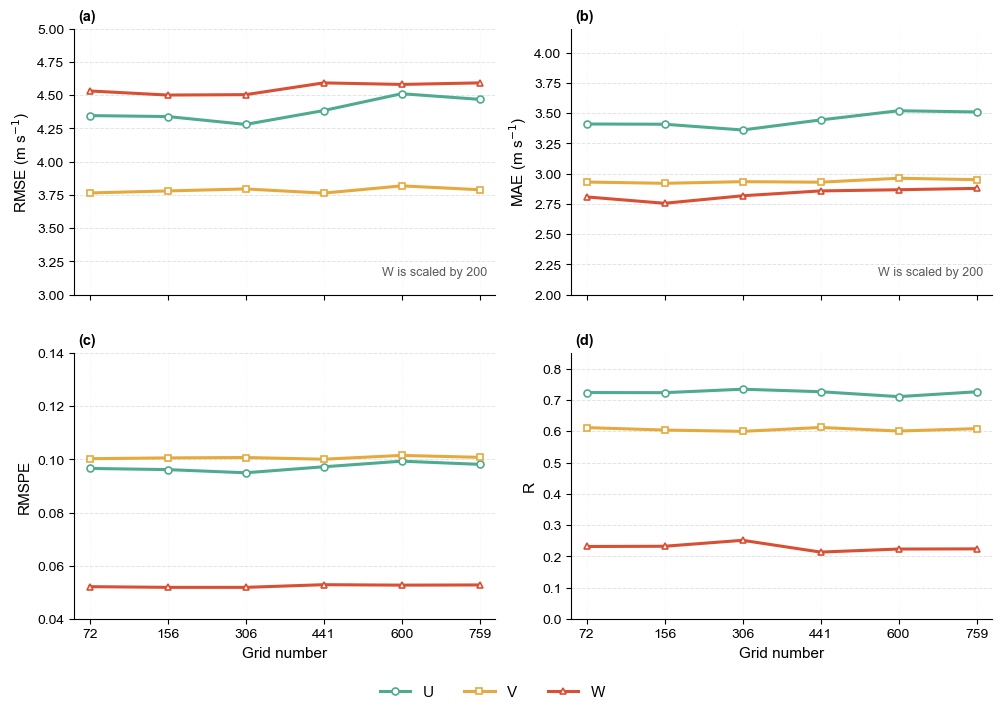

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. 基本设置
# =========================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# 把 Grid Number 当作离散实验设置，使用等间距分类轴
grid_labels = ["72", "156", "306", "441", "600", "759"]
x = np.arange(len(grid_labels))

# 颜色：沿用你之前的风格，但做得更稳一点
COLOR_U = "#4EAB90"
COLOR_V = "#E6A93D"
COLOR_W = "#D94F33"

MARKER_U = "o"
MARKER_V = "s"
MARKER_W = "^"

# =========================================================
# 2. 数据
# =========================================================
rmse_data = {
    "U": np.array(u_rmse, dtype=float),
    "V": np.array(v_rmse, dtype=float),
    "W": np.array(w_rmse, dtype=float),
}
mae_data = {
    "U": np.array(u_mae, dtype=float),
    "V": np.array(v_mae, dtype=float),
    "W": np.array(w_mae, dtype=float),
}
rmspe_data = {
    "U": np.array(u_rmspe, dtype=float),
    "V": np.array(v_rmspe, dtype=float),
    "W": np.array(w_rmspe, dtype=float),
}
r_data = {
    "U": np.array(u_r, dtype=float),
    "V": np.array(v_r, dtype=float),
    "W": np.array(w_r, dtype=float),
}

panel_data = [
    ("RMSE (m s$^{-1}$)", rmse_data),
    ("MAE (m s$^{-1}$)", mae_data),
    ("RMSPE", rmspe_data),
    ("R", r_data),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

color_map = {"U": COLOR_U, "V": COLOR_V, "W": COLOR_W, "W": COLOR_W}
marker_map = {"U": MARKER_U, "V": MARKER_V, "W": MARKER_W, "W": MARKER_W}

# =========================================================
# 3. 绘图
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(10.2, 7.2), sharex=True)
axes = axes.flatten()

for i, (ylabel, data_dict) in enumerate(panel_data):
    ax = axes[i]

    for name, y in data_dict.items():
        ax.plot(
            x, y,
            color=color_map[name],
            linewidth=2.2,
            marker=marker_map[name],
            markersize=5.0,
            markerfacecolor="white",
            markeredgewidth=1.2,
            label=name
        )

    # panel label
    ax.text(
        0.01, 1.02, panel_labels[i],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=10.5, fontweight="bold"
    )

    # 轴设置
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(grid_labels)
    ax.set_xlim(-0.2, len(x) - 1 + 0.2)

    # 网格线
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.18)

    # 去掉上、右边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# 底行才显示 x 轴标题
axes[2].set_xlabel("Grid number")
axes[3].set_xlabel("Grid number")

# =========================================================
# 4. 手动调整 y 轴范围，让图更紧凑好看
# =========================================================
# (a) RMSE
axes[0].set_ylim(3.0, 5.0)

# (b) MAE
axes[1].set_ylim(2.0, 4.2)

# (c) RMSPE
axes[2].set_ylim(0.04, 0.14)

# (d) R
axes[3].set_ylim(0.0, 0.85)

# 在前两幅图中提醒 W 做了 ×200
axes[0].text(
    0.98, 0.06, "W is scaled by 200",
    transform=axes[0].transAxes,
    ha="right", va="bottom",
    fontsize=9, color="0.35"
)
axes[1].text(
    0.98, 0.06, "W is scaled by 200",
    transform=axes[1].transAxes,
    ha="right", va="bottom",
    fontsize=9, color="0.35"
)

# =========================================================
# 5. 共享图例
# =========================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=11
)

fig.subplots_adjust(
    left=0.09,
    right=0.99,
    top=0.96,
    bottom=0.14,
    wspace=0.18,
    hspace=0.22
)

plt.show()

# 保存
# fig.savefig(r"E:\huawei\result\Fig9_revised.png", dpi=600, bbox_inches="tight")

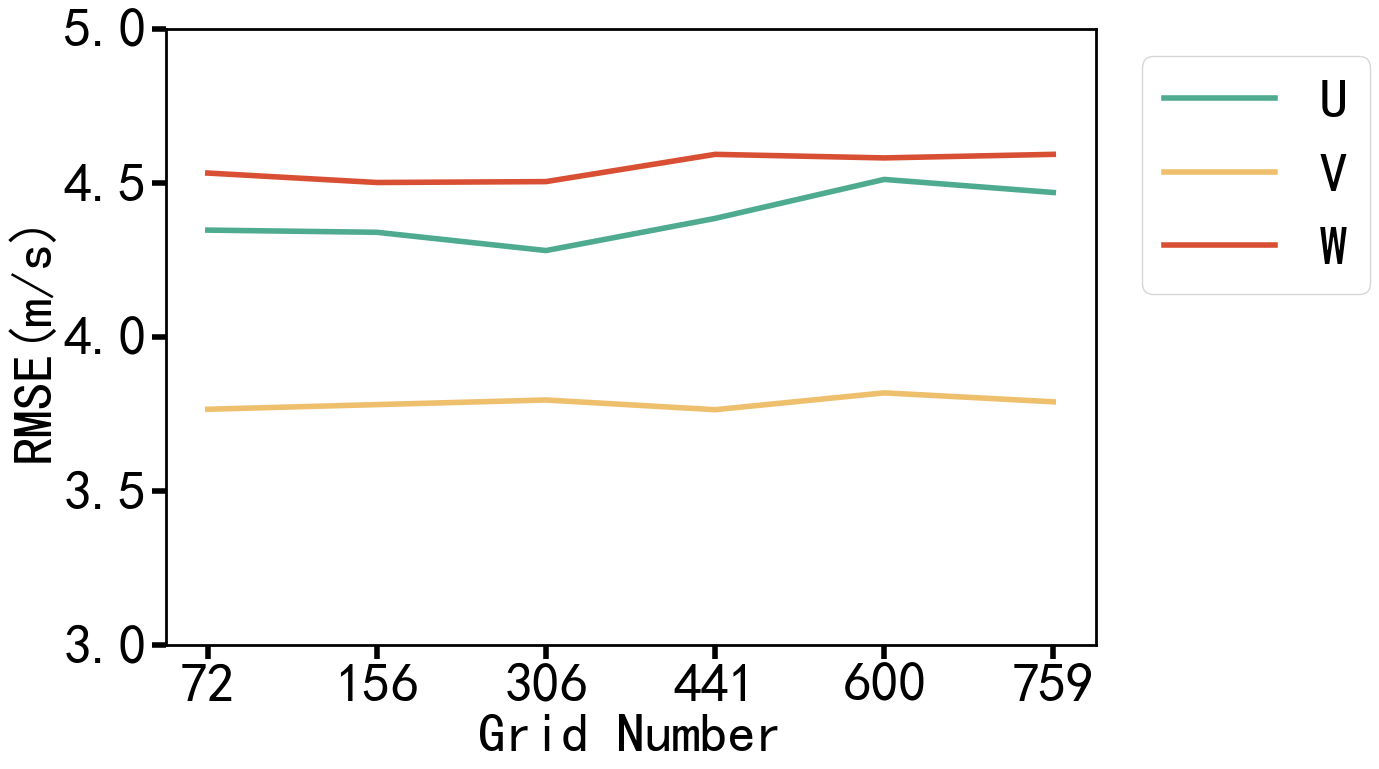

<Figure size 640x480 with 0 Axes>

In [5]:
regressline,ym,yf,yd=Autobar_or_line([u_rmse,v_rmse,w_rmse],['72','156','306','441','600','759'],None,'no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=None,selfvmin=None,linenum=3,xlabelname='Grid Number',ylabelname='RMSE(m/s)',bar_line_title='',label=['U','V','W'],linewidth=4,selfcolor=['#4EAB90','#EEBF6D','#D94F33'],selflinestyle=['-','-','-'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=1,labelsize=40,xlabelformat='self',valuemodel='+',bar_text='no')

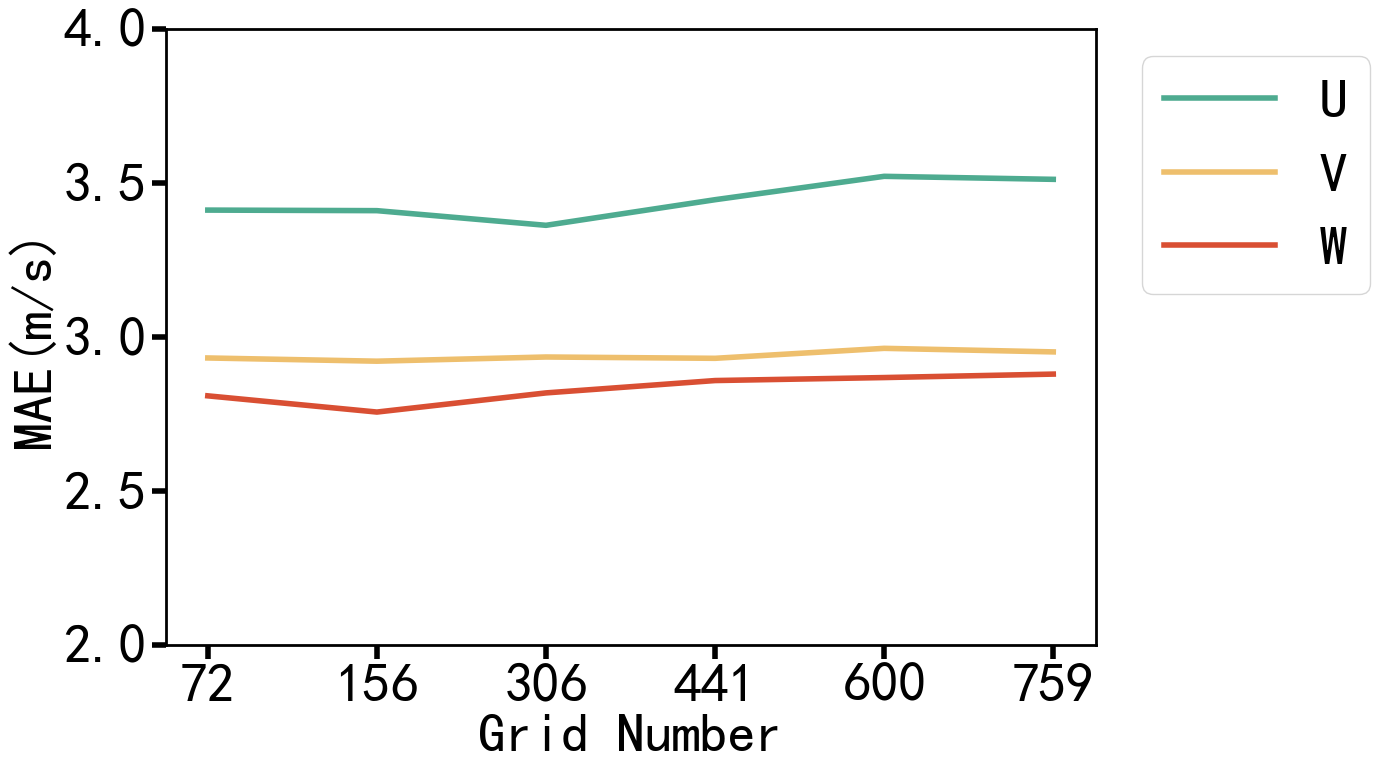

<Figure size 640x480 with 0 Axes>

In [6]:
regressline,ym,yf,yd=Autobar_or_line([u_mae,v_mae,w_mae],['72','156','306','441','600','759'],None,'no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=None,selfvmin=None,linenum=3,xlabelname='Grid Number',ylabelname='MAE(m/s)',bar_line_title='',label=['U','V','W'],linewidth=4,selfcolor=['#4EAB90','#EEBF6D','#D94F33'],selflinestyle=['-','-','-'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=1,labelsize=40,xlabelformat='self',valuemodel='+',bar_text='no')

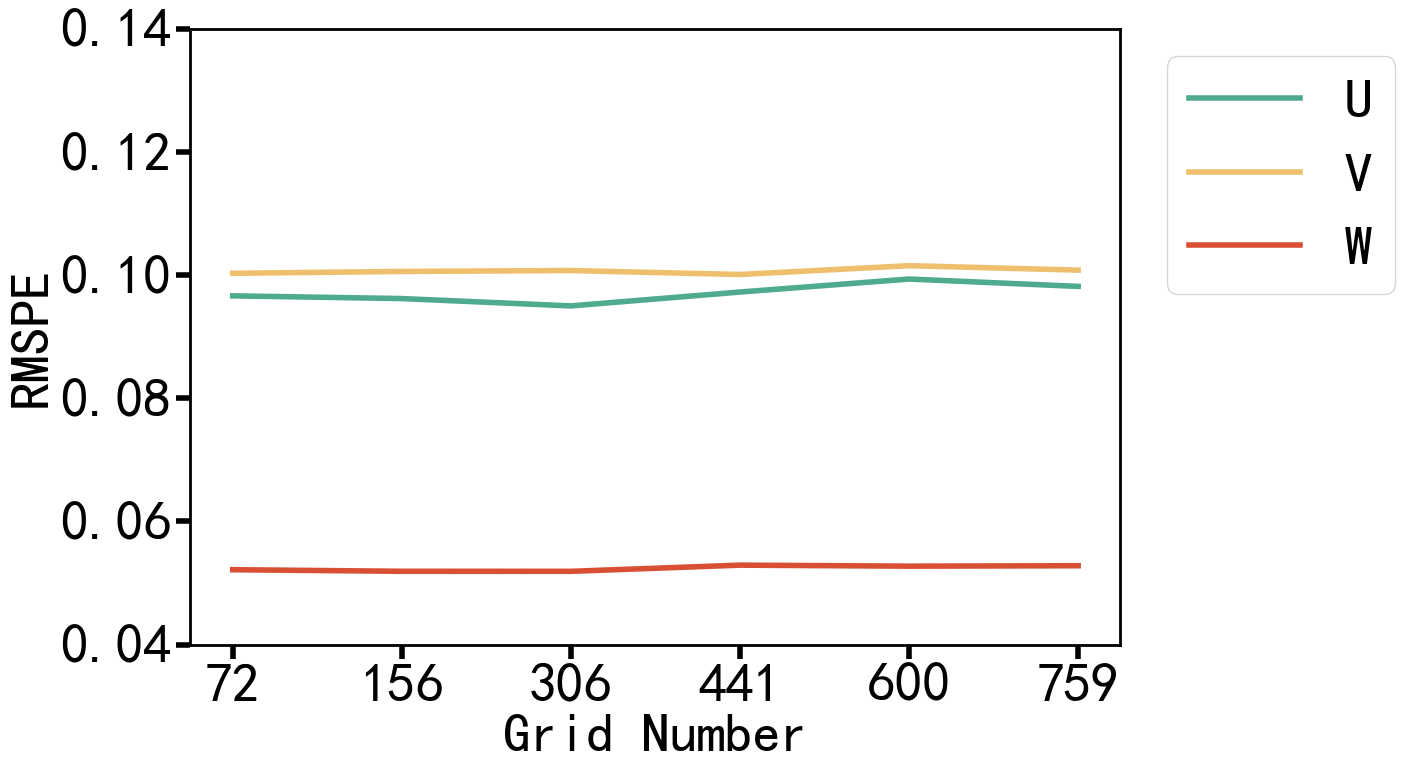

<Figure size 640x480 with 0 Axes>

In [9]:
regressline,ym,yf,yd=Autobar_or_line([u_rmspe,v_rmspe,w_rmspe],['72','156','306','441','600','759'],None,'no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=0.14,selfvmin=0.04,linenum=3,xlabelname='Grid Number',ylabelname='RMSPE',bar_line_title='',label=['U','V','W'],linewidth=4,selfcolor=['#4EAB90','#EEBF6D','#D94F33'],selflinestyle=['-','-','-'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=1,labelsize=40,xlabelformat='self',valuemodel='+',bar_text='no')

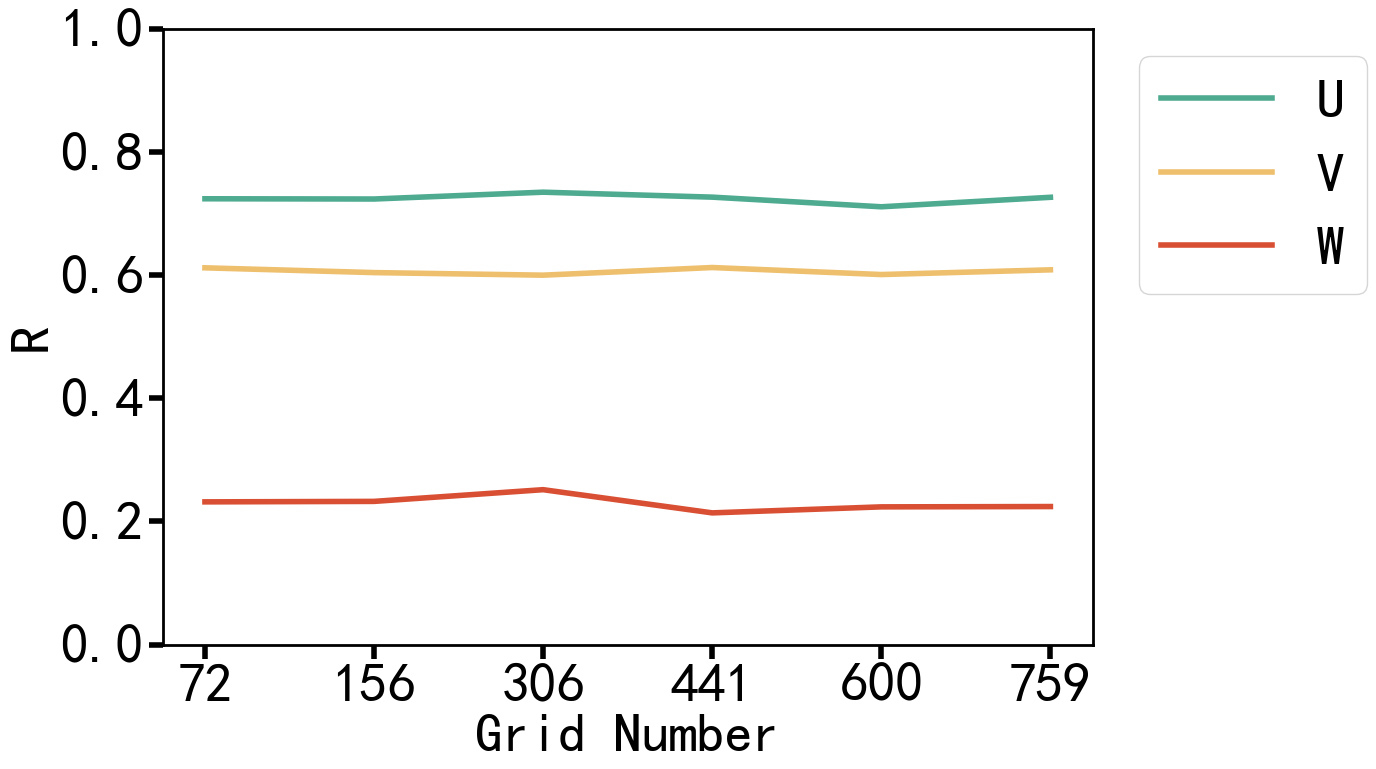

<Figure size 640x480 with 0 Axes>

In [10]:
regressline,ym,yf,yd=Autobar_or_line([u_r,v_r,w_r],['72','156','306','441','600','759'],None,'no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=0.14,selfvmin=0.04,linenum=3,xlabelname='Grid Number',ylabelname='R',bar_line_title='',label=['U','V','W'],linewidth=4,selfcolor=['#4EAB90','#EEBF6D','#D94F33'],selflinestyle=['-','-','-'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=1,labelsize=40,xlabelformat='self',valuemodel='+',bar_text='no')

In [16]:
import Auto_paint_self
import xarray as xr
testy_u_file=xr.open_dataset('E:/huawei/result/cnn_transformer_test_u_6_5year_order_fusion_72.nc')
predicty_u_file=xr.open_dataset('E:/huawei/result/cnn_transformer_predicty_u_6_5year_order_fusion_72.nc')
testy_v_file=xr.open_dataset('E:/huawei/result/cnn_transformer_testy_v_6_5year_order_fusion_72.nc')
predicty_v_file=xr.open_dataset('E:/huawei/result/cnn_transformer_predicty_v_6_5year_order_fusion_72.nc')
testy_w_file=xr.open_dataset('E:/huawei/result/cnn_transformer_testy_w_6_5year_order_fusion_72.nc')
predicty_w_file=xr.open_dataset('E:/huawei/result/cnn_transformer_predicty_w_6_5year_order_fusion_72.nc')

In [17]:
import numpy as np
testy_u_0=np.array(testy_u_file['testy_u'])
testy_v_0=np.array(testy_v_file['testy_v'])
testy_w_0=np.array(testy_w_file['testy_w'])
predicty_u_0=np.array(predicty_u_file['predicty_u'])
predicty_v_0=np.array(predicty_v_file['predicty_v'])
predicty_w_0=np.array(predicty_w_file['predicty_w'])

In [18]:
times=testy_u_file['time']

In [19]:
import numpy as np
import pandas as pd

# --- 0. 假设您的原始数据已经加载到以下变量中 ---
# 请确保这些变量在您的环境中是可用的，并且具有正确的维度。
# 您的数据维度信息：
# time_dim = 8759
# level_dim = 7
#
# 例如，如果您的数据是从 xarray.Dataset 中读取的：
# import xarray as xr
# ds_test = xr.open_dataset('your_test_data.nc')
# ds_predict = xr.open_dataset('your_predict_data.nc')

# testy_u_0 = ds_test['u_variable'].values # 假设 'u_variable' 是 u 风速的变量名
# testy_v_0 = ds_test['v_variable'].values
# testy_w_0 = ds_test['w_variable'].values
# predicty_u_0 = ds_predict['u_variable'].values
# predicty_v_0 = ds_predict['v_variable'].values
# predicty_w_0 = ds_predict['w_variable'].values

# times = ds_test['time'].values # 确保 times 是一个 Pandas DatetimeIndex 或 NumPy 数组

# --- 临时占位符 (请务必用您的实际数据替换此部分！) ---
# 由于您要求删除虚拟数据生成，我在这里放置了占位符，
# 您需要确保在运行此代码之前，以下变量已经包含您的实际数据。
# 为了使代码可运行，我暂时使用一些简单的模拟数据，但请您用实际数据替换。
# 请删除或注释掉此内部模拟数据块，并取消注释并使用您自己的数据加载代码。
if 'testy_u_0' not in locals() or 'predicty_u_0' not in locals():
    print("警告: 实际数据变量未找到。正在使用内部模拟数据进行演示。")
    # 内部模拟数据，仅为使代码可运行
    time_dim = 8759
    level_dim = 7
    times = pd.date_range(start='2023-01-01 00:00:00', periods=time_dim, freq='H')
    np.random.seed(42)
    testy_u_0 = (15 + 3 * np.sin(np.linspace(0, 8 * np.pi, time_dim)))[:, np.newaxis] \
                + np.random.randn(time_dim, level_dim) * 2
    predicty_u_0 = (16.5 + 3.2 * np.sin(np.linspace(0, 8 * np.pi, time_dim) + 0.1))[:, np.newaxis] \
                   + np.random.randn(time_dim, level_dim) * 2.5
    testy_v_0 = (5 + 2 * np.cos(np.linspace(0, 8 * np.pi, time_dim)))[:, np.newaxis] \
                + np.random.randn(time_dim, level_dim) * 1.5
    predicty_v_0 = testy_v_0 + np.random.randn(time_dim, level_dim) * 1
    testy_w_0 = (0.1 + 0.05 * np.sin(np.linspace(0, 8 * np.pi, time_dim)))[:, np.newaxis] \
                + np.random.randn(time_dim, level_dim) * 0.05
    predicty_w_0 = testy_w_0 + np.random.randn(time_dim, level_dim) * 0.03
    for arr in [testy_u_0, testy_v_0, testy_w_0, predicty_u_0, predicty_v_0, predicty_w_0]:
        arr[np.random.rand(*arr.shape) < 0.01] = np.nan
# --- 临时占位符结束 ---

# 验证数据维度
if testy_u_0.ndim != 2 or predicty_u_0.ndim != 2:
    raise ValueError("输入数据维度不正确。预期形状为 (time, level)。")
time_dim = testy_u_0.shape[0]
level_dim = testy_u_0.shape[1]

print(f"原始数据形状示例: testy_u_0.shape = {testy_u_0.shape}")
print(f"时间维度长度: {time_dim}, 层数维度长度: {level_dim}")

# --- 辅助函数：获取围绕指定中心索引的窗口索引 ---
def get_centered_window_indices(N_total, window_size, center_idx):
    """
    在 N_total 个点中，获取围绕 center_idx 的 window_size 个点的索引。
    处理边界情况，确保窗口不超出范围。
    """
    if N_total < window_size:
        return np.arange(N_total) # 如果总点数不足，返回所有点

    # 计算理想的起始和结束索引
    start_idx = center_idx - window_size // 2
    end_idx = center_idx + (window_size - window_size // 2) # 确保总长度为 window_size

    # 调整以处理边界情况
    if start_idx < 0:
        start_idx = 0
        end_idx = window_size
    elif end_idx > N_total:
        end_idx = N_total
        start_idx = N_total - window_size
    
    return np.arange(start_idx, end_idx)

# --- 1. 定义需要处理的变量名和层索引 ---
target_level_indices = [0, 4, 6] # 您指定的第二维固定索引
variables = ['u', 'v', 'w']
data_sets = ['testy', 'predicty'] # 前缀

# 用于存储结果的字典
extracted_series_best_fit = {}
extracted_times_best_fit = {}
extracted_series_avg_diff = {}
extracted_times_avg_diff = {}
extracted_series_25th_diff = {} # NEW: 25分位差异
extracted_times_25th_diff = {} # NEW: 25分位差异对应时间


# --- 2. 循环处理每个目标层和每个变量 ---
for level_idx in target_level_indices:
    # 检查层索引是否有效
    if level_idx >= level_dim:
        print(f"警告: 层索引 {level_idx} 超出数据范围 (最大索引 {level_dim - 1})。跳过此层。")
        continue

    print(f"\n--- 处理层索引: {level_idx} ---")

    for var_name in variables: # 现在对每个变量独立进行筛选
        print(f"  - 筛选变量: {var_name}")

        # 获取当前变量的 testy 和 predicty 时间序列
        testy_for_level_var = globals()[f"testy_{var_name}_0"][:, level_idx]
        predicty_for_level_var = globals()[f"predicty_{var_name}_0"][:, level_idx]
        
        # 找到 testy 和 predicty 都有有效值（非NaN）的那些时间步
        valid_mask = ~np.isnan(testy_for_level_var) & ~np.isnan(predicty_for_level_var)
        
        # 提取这些有效数据
        valid_testy_var = testy_for_level_var[valid_mask]
        valid_predicty_var = predicty_for_level_var[valid_mask]
        
        # 记录这些有效时间步在原始时间序列 (长度为 time_dim) 中的索引
        original_time_indices_of_valid_points = np.where(valid_mask)[0]
        
        N_valid = len(valid_testy_var) # 共同有效数据点的总数
        print(f"    - 变量 {var_name} 在层 {level_idx} 共有 {N_valid} 个共同有效的时间步。")

        # 初始化选择的索引列表
        indices_to_select_from_valid_data_best_fit = []
        indices_to_select_from_valid_data_avg_diff = []
        indices_to_select_from_valid_data_25th_diff = []

        if N_valid < 100:
            print(f"    - 警告: 变量 {var_name} 在层 {level_idx} 的共同有效数据点不足100个 ({N_valid})。将选择所有有效点。")
            all_valid_indices = np.arange(N_valid)
            indices_to_select_from_valid_data_best_fit = all_valid_indices
            indices_to_select_from_valid_data_avg_diff = all_valid_indices
            indices_to_select_from_valid_data_25th_diff = all_valid_indices
        else:
            # 计算 testy 和 predicty 之间在有效时间步的绝对差值
            absolute_differences = np.abs(valid_testy_var - valid_predicty_var)
            
            # 获取排序后的索引，这些索引对应于差值从小到大排列
            sorted_indices_by_diff = np.argsort(absolute_differences)
            
            # --- 拟合最好的前100个值 (针对当前变量) ---
            indices_to_select_from_valid_data_best_fit = sorted_indices_by_diff[:100]
            
            # --- 差异平均水平的100个值 (围绕中位数) ---
            median_center_idx = N_valid // 2
            relative_indices_avg_diff = get_centered_window_indices(N_valid, 100, median_center_idx)
            indices_to_select_from_valid_data_avg_diff = sorted_indices_by_diff[relative_indices_avg_diff]

            # --- 25分位差异水平的100个值 (围绕25分位点) ---
            percentile_25_center_idx = int(0.25 * N_valid)
            relative_indices_25th_diff = get_centered_window_indices(N_valid, 100, percentile_25_center_idx)
            indices_to_select_from_valid_data_25th_diff = sorted_indices_by_diff[relative_indices_25th_diff]
            
        # 将这些选择的有效数据索引映射回原始时间序列的索引
        selected_original_time_indices_best_fit = original_time_indices_of_valid_points[indices_to_select_from_valid_data_best_fit]
        selected_original_time_indices_avg_diff = original_time_indices_of_valid_points[indices_to_select_from_valid_data_avg_diff]
        selected_original_time_indices_25th_diff = original_time_indices_of_valid_points[indices_to_select_from_valid_data_25th_diff]
            
        print(f"    - 选定了 {len(selected_original_time_indices_best_fit)} 个时间步的原始索引 (拟合最好)。")
        print(f"    - 选定了 {len(selected_original_time_indices_avg_diff)} 个时间步的原始索引 (差异平均水平)。")
        print(f"    - 选定了 {len(selected_original_time_indices_25th_diff)} 个时间步的原始索引 (25分位差异)。")

        # 步骤2.3: 使用这些选定的时间索引，从所有数据集中提取当前变量的数据
        for data_set_prefix in data_sets:
            current_var_full_name = f"{data_set_prefix}_{var_name}_0"
            current_data_array = globals()[current_var_full_name]
            series_for_current_var_level = current_data_array[:, level_idx] # 提取当前变量在当前层的时间序列
            
            # --- 提取拟合最好的前100个值 ---
            new_series_best_fit = series_for_current_var_level[selected_original_time_indices_best_fit]
            key_best_fit = f"{data_set_prefix}_{var_name}_level{level_idx}_best_fit"
            extracted_series_best_fit[key_best_fit] = new_series_best_fit
            extracted_times_best_fit[key_best_fit] = times[selected_original_time_indices_best_fit]
            
            # --- 提取差异平均水平的100个值 ---
            new_series_avg_diff = series_for_current_var_level[selected_original_time_indices_avg_diff]
            key_avg_diff = f"{data_set_prefix}_{var_name}_level{level_idx}_avg_diff"
            extracted_series_avg_diff[key_avg_diff] = new_series_avg_diff
            extracted_times_avg_diff[key_avg_diff] = times[selected_original_time_indices_avg_diff]

            # --- 提取25分位差异水平的100个值 ---
            new_series_25th_diff = series_for_current_var_level[selected_original_time_indices_25th_diff]
            key_25th_diff = f"{data_set_prefix}_{var_name}_level{level_idx}_25th_diff"
            extracted_series_25th_diff[key_25th_diff] = new_series_25th_diff
            extracted_times_25th_diff[key_25th_diff] = times[selected_original_time_indices_25th_diff]
            
            print(f"    - 生成了 {key_best_fit}, {key_avg_diff}, {key_25th_diff}")

# --- 3. 提供最终变量 (完整展开) ---
print("\n--- 最终变量已生成并赋值 ---")

# 辅助函数，用于动态创建变量并赋值
def assign_variable(name, value):
    globals()[name] = value
    if value is not None:
        pass # 打印信息在主循环中已经足够
    else:
        print(f"警告: 变量 '{name}' 为 None (数据可能不足或未加载)。")

# 完整展开所有变量的赋值
for level_idx in target_level_indices:
    level_str = str(level_idx) # 用于构建变量名中的层级部分，例如 '0', '4', '6'
    
    for var_name in variables:
        for data_set_prefix in data_sets:
            # 拟合最好的前100个值
            key_best_fit = f"{data_set_prefix}_{var_name}_level{level_idx}_best_fit"
            var_name_best_fit = f"{data_set_prefix}_{var_name}_{level_str}_0_best_fit" # 您的命名格式
            assign_variable(var_name_best_fit, extracted_series_best_fit.get(key_best_fit))

            # 差异平均水平的100个值
            key_avg_diff = f"{data_set_prefix}_{var_name}_level{level_idx}_avg_diff"
            var_name_avg_diff = f"{data_set_prefix}_{var_name}_{level_str}_0_avg_diff" # 您的命名格式
            assign_variable(var_name_avg_diff, extracted_series_avg_diff.get(key_avg_diff))

            # 25分位差异水平的100个值
            key_25th_diff = f"{data_set_prefix}_{var_name}_level{level_idx}_25th_diff"
            var_name_25th_diff = f"{data_set_prefix}_{var_name}_{level_str}_0_25th_diff" # 您的命名格式
            assign_variable(var_name_25th_diff, extracted_series_25th_diff.get(key_25th_diff))

# 打印一些示例值进行验证
print("\n--- 示例变量内容 ---")

# 示例：testy_u_0_0_best_fit
if 'testy_u_0_0_best_fit' in globals() and globals()['testy_u_0_0_best_fit'] is not None:
    print(f"\n变量 'testy_u_0_0_best_fit' (u变量，层0，拟合最好) 的长度: {len(globals()['testy_u_0_0_best_fit'])}")
    print(f"前5个值:\n{globals()['testy_u_0_0_best_fit'][:5]}")
    print(f"对应的时间戳前5个为:\n{extracted_times_best_fit['testy_u_level0_best_fit'][:5]}")
else:
    print("\n变量 'testy_u_0_0_best_fit' 未能成功创建或为None。")

# 示例：predicty_v_4_0_avg_diff
if 'predicty_v_4_0_avg_diff' in globals() and globals()['predicty_v_4_0_avg_diff'] is not None:
    print(f"\n变量 'predicty_v_4_0_avg_diff' (v变量，层4，差异平均水平) 的长度: {len(globals()['predicty_v_4_0_avg_diff'])}")
    print(f"前5个值:\n{globals()['predicty_v_4_0_avg_diff'][:5]}")
    print(f"对应的时间戳前5个为:\n{extracted_times_avg_diff['predicty_v_level4_avg_diff'][:5]}")
else:
    print("\n变量 'predicty_v_4_0_avg_diff' 未能成功创建或为None。")

# 示例：testy_w_6_0_25th_diff
if 'testy_w_6_0_25th_diff' in globals() and globals()['testy_w_6_0_25th_diff'] is not None:
    print(f"\n变量 'testy_w_6_0_25th_diff' (w变量，层6，25分位差异) 的长度: {len(globals()['testy_w_6_0_25th_diff'])}")
    print(f"前5个值:\n{globals()['testy_w_6_0_25th_diff'][:5]}")
    print(f"对应的时间戳前5个为:\n{extracted_times_25th_diff['testy_w_level6_25th_diff'][:5]}")
else:
    print("\n变量 'testy_w_6_0_25th_diff' 未能成功创建或为None。")

print("\n所有请求的变量已根据您的命名约定生成并存储在全局命名空间中。")
# 您现在可以使用这些变量 (例如 testy_u_0_0_best_fit, predicty_v_4_0_avg_diff, testy_w_6_0_25th_diff) 进行您自己的绘图。

原始数据形状示例: testy_u_0.shape = (8759, 7)
时间维度长度: 8759, 层数维度长度: 7

--- 处理层索引: 0 ---
  - 筛选变量: u
    - 变量 u 在层 0 共有 8759 个共同有效的时间步。
    - 选定了 100 个时间步的原始索引 (拟合最好)。
    - 选定了 100 个时间步的原始索引 (差异平均水平)。
    - 选定了 100 个时间步的原始索引 (25分位差异)。
    - 生成了 testy_u_level0_best_fit, testy_u_level0_avg_diff, testy_u_level0_25th_diff
    - 生成了 predicty_u_level0_best_fit, predicty_u_level0_avg_diff, predicty_u_level0_25th_diff
  - 筛选变量: v
    - 变量 v 在层 0 共有 8759 个共同有效的时间步。
    - 选定了 100 个时间步的原始索引 (拟合最好)。
    - 选定了 100 个时间步的原始索引 (差异平均水平)。
    - 选定了 100 个时间步的原始索引 (25分位差异)。
    - 生成了 testy_v_level0_best_fit, testy_v_level0_avg_diff, testy_v_level0_25th_diff
    - 生成了 predicty_v_level0_best_fit, predicty_v_level0_avg_diff, predicty_v_level0_25th_diff
  - 筛选变量: w
    - 变量 w 在层 0 共有 8759 个共同有效的时间步。
    - 选定了 100 个时间步的原始索引 (拟合最好)。
    - 选定了 100 个时间步的原始索引 (差异平均水平)。
    - 选定了 100 个时间步的原始索引 (25分位差异)。
    - 生成了 testy_w_level0_best_fit, testy_w_level0_avg_diff, testy_w_level0_25th_diff
    - 生成了 predicty_w_level0_best_fit

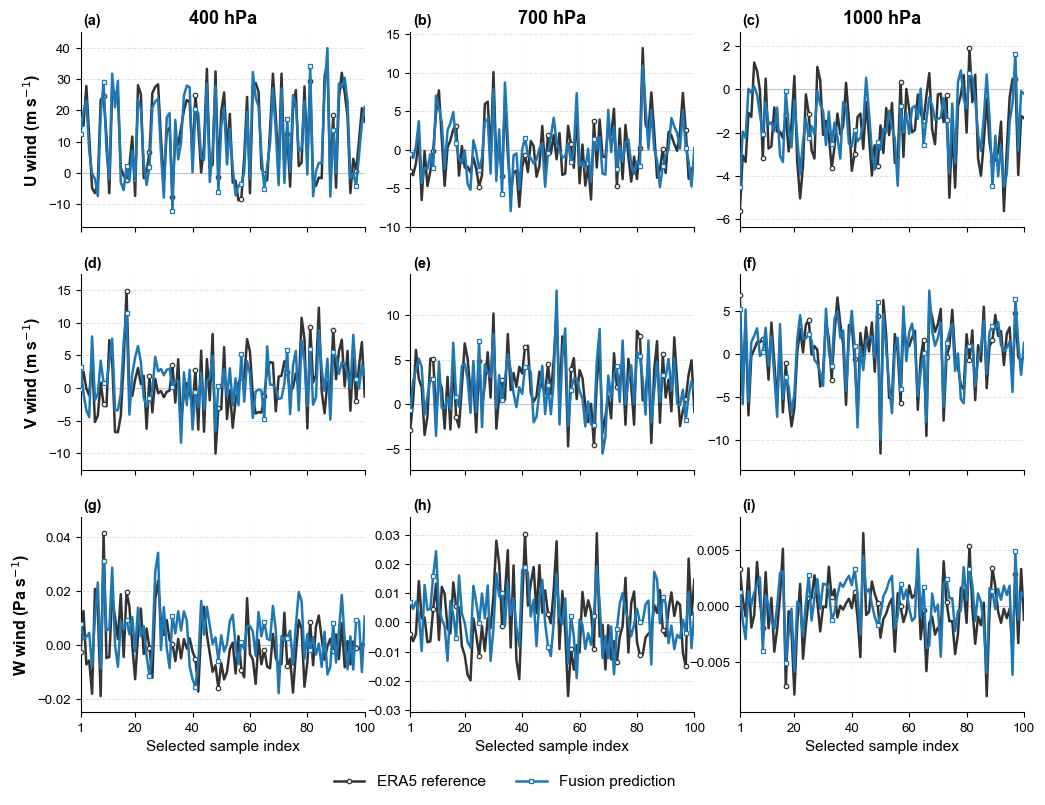

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. 基本风格
# =========================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.titlesize": 13,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})

# 颜色：ERA5 用黑灰，预测值用蓝色，更稳、更像论文图
COLOR_TEST = "#333333"
COLOR_PRED = "#1f77b4"

MARKER_TEST = "o"
MARKER_PRED = "s"

# =========================================================
# 2. 把 9 个子图数据整理起来
#    行：U / V / W
#    列：400 / 700 / 1000 hPa
# =========================================================
panel_data = [
    # row 1: U
    ("400 hPa", "U wind (m s$^{-1}$)", testy_u_0_0_avg_diff, predicty_u_0_0_avg_diff),
    ("700 hPa", "U wind (m s$^{-1}$)", testy_u_4_0_avg_diff, predicty_u_4_0_avg_diff),
    ("1000 hPa", "U wind (m s$^{-1}$)", testy_u_6_0_avg_diff, predicty_u_6_0_avg_diff),

    # row 2: V
    ("400 hPa", "V wind (m s$^{-1}$)", testy_v_0_0_avg_diff, predicty_v_0_0_avg_diff),
    ("700 hPa", "V wind (m s$^{-1}$)", testy_v_4_0_avg_diff, predicty_v_4_0_avg_diff),
    ("1000 hPa", "V wind (m s$^{-1}$)", testy_v_6_0_avg_diff, predicty_v_6_0_avg_diff),

    # row 3: W
    ("400 hPa", "W wind (Pa s$^{-1}$)", testy_w_0_0_avg_diff, predicty_w_0_0_avg_diff),
    ("700 hPa", "W wind (Pa s$^{-1}$)", testy_w_4_0_avg_diff, predicty_w_4_0_avg_diff),
    ("1000 hPa", "W wind (Pa s$^{-1}$)", testy_w_6_0_avg_diff, predicty_w_6_0_avg_diff),
]

panel_labels = ["(a)", "(b)", "(c)",
                "(d)", "(e)", "(f)",
                "(g)", "(h)", "(i)"]

# =========================================================
# 3. 自动设置更舒服的 y 轴范围
# =========================================================
def get_ylim(y1, y2, pad_frac=0.10):
    y = np.concatenate([np.asarray(y1, dtype=float), np.asarray(y2, dtype=float)])
    y = y[np.isfinite(y)]
    if len(y) == 0:
        return -1, 1
    ymin, ymax = np.min(y), np.max(y)
    if np.isclose(ymin, ymax):
        pad = 0.1 * max(abs(ymin), 1.0)
    else:
        pad = (ymax - ymin) * pad_frac
    return ymin - pad, ymax + pad

# =========================================================
# 4. 绘图
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(10.6, 8.2), sharex=True)
axes = axes.flatten()

legend_handles = None
legend_labels = None

for i, ax in enumerate(axes):
    title, ylabel, y_test, y_pred = panel_data[i]

    y_test = np.asarray(y_test, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = min(len(y_test), len(y_pred))
    x = np.arange(1, n + 1)

    # 两条线
    l1, = ax.plot(
        x, y_test[:n],
        color=COLOR_TEST,
        linewidth=1.8,
        marker=MARKER_TEST,
        markersize=3.2,
        markerfacecolor="white",
        markeredgewidth=0.9,
        markevery=max(1, n // 12),
        label="ERA5 reference",
        zorder=3
    )
    l2, = ax.plot(
        x, y_pred[:n],
        color=COLOR_PRED,
        linewidth=1.8,
        marker=MARKER_PRED,
        markersize=3.0,
        markerfacecolor="white",
        markeredgewidth=0.9,
        markevery=max(1, n // 12),
        label="Fusion prediction",
        zorder=3
    )

    if legend_handles is None:
        legend_handles = [l1, l2]
        legend_labels = ["ERA5 reference", "Fusion prediction"]

    # 零值参考线（对 V/W 特别有帮助；U 画上也不影响）
    ax.axhline(0, color="0.80", linewidth=0.8, zorder=1)

    # 只在第一行写列标题
    if i < 3:
        ax.set_title(title, pad=6, fontweight="bold")

    # 只在第一列写 y 轴标签
    if i % 3 == 0:
        ax.set_ylabel(ylabel, fontsize=11.5, fontweight="bold")

    # 子图标签
    ax.text(
        0.01, 1.02, panel_labels[i],
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=10.5, fontweight="bold"
    )

    # 网格线
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.18)

    # 去掉右、上边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # x 轴范围和刻度
    ax.set_xlim(1, n)
    if n >= 100:
        ax.set_xticks([1, 20, 40, 60, 80, 100])
    else:
        ax.set_xticks(np.linspace(1, n, 6, dtype=int))

    # y 轴范围自动设置
    ymin, ymax = get_ylim(y_test[:n], y_pred[:n], pad_frac=0.10)
    ax.set_ylim(ymin, ymax)

# 只在底行显示 x 轴标签
for ax in axes[6:]:
    ax.set_xlabel("Selected sample index", fontsize=11)

# 共享图例
fig.legend(
    legend_handles, legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=11
)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    top=0.95,
    bottom=0.12,
    wspace=0.16,
    hspace=0.24
)

plt.show()

# 保存
# fig.savefig(r"E:\huawei\result\Fig10_revised.png", dpi=600, bbox_inches="tight")

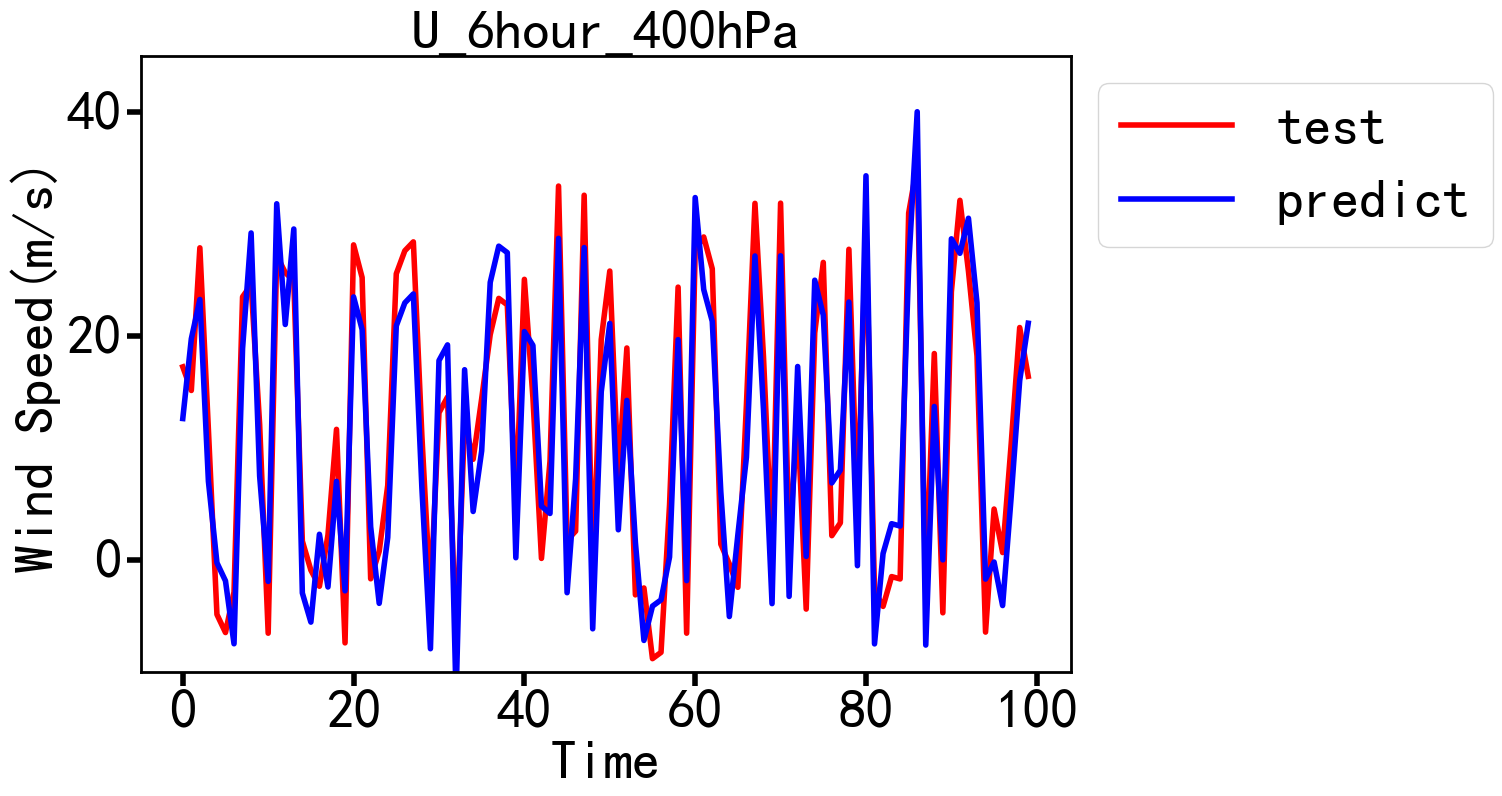

<Figure size 640x480 with 0 Axes>

In [250]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_u_0_0_avg_diff,predicty_u_0_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=45,selfvmin=-10,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='U_6hour_400hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

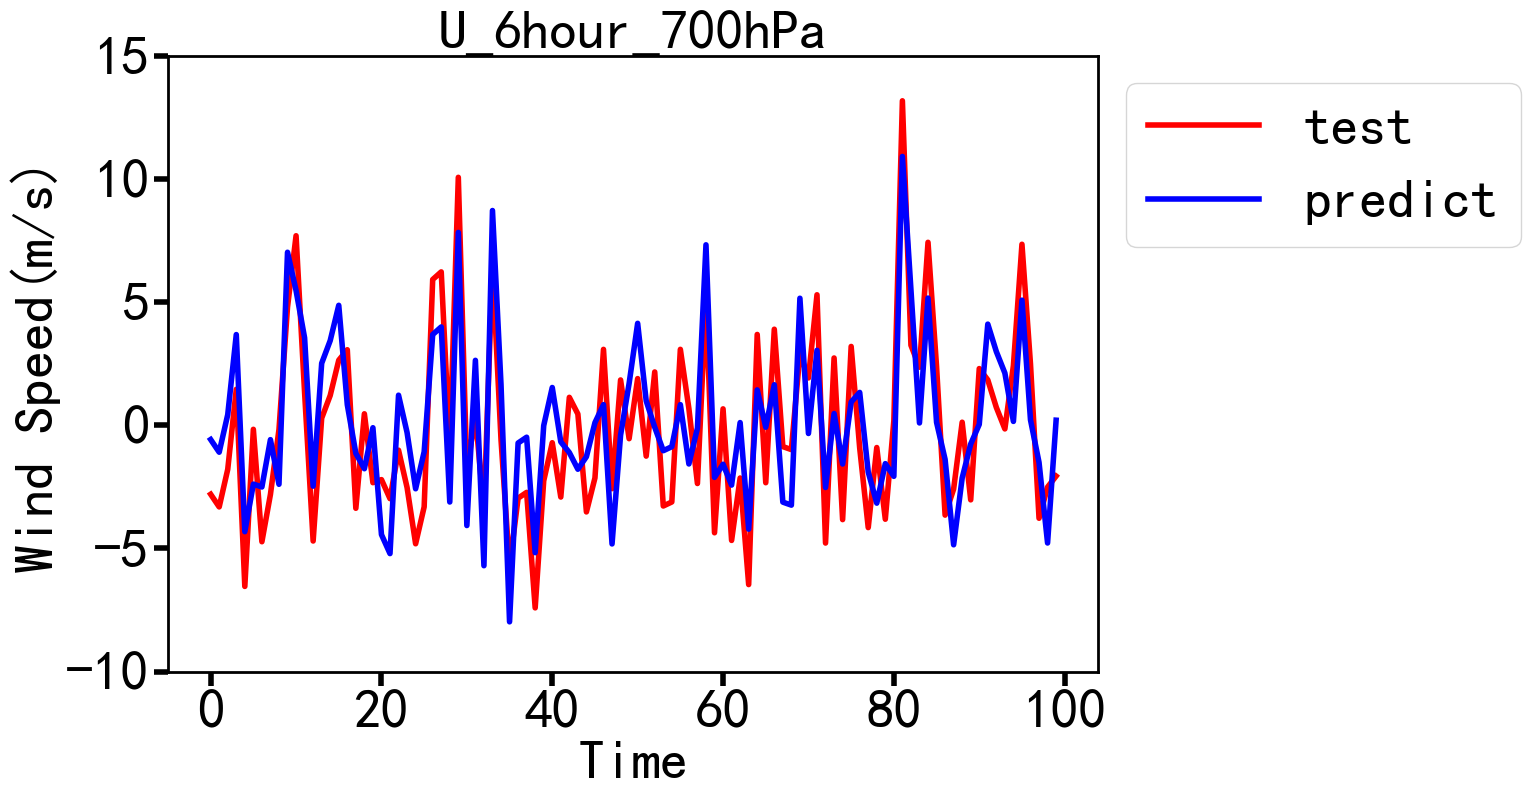

<Figure size 640x480 with 0 Axes>

In [251]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_u_4_0_avg_diff,predicty_u_4_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=15,selfvmin=-10,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='U_6hour_700hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

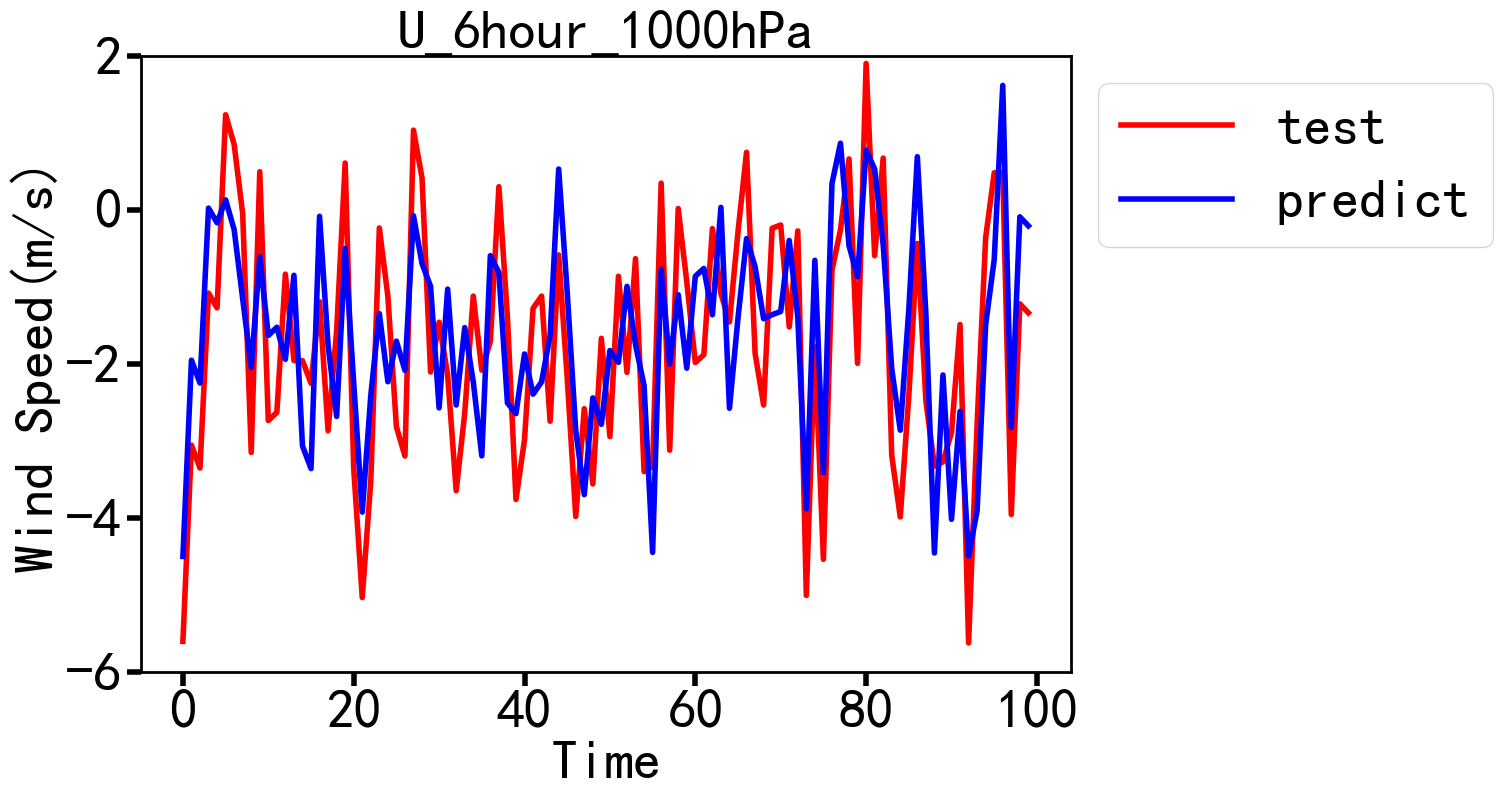

<Figure size 640x480 with 0 Axes>

In [224]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_u_6_0_avg_diff,predicty_u_6_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=0.08,selfvmin=0.04,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='U_6hour_1000hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

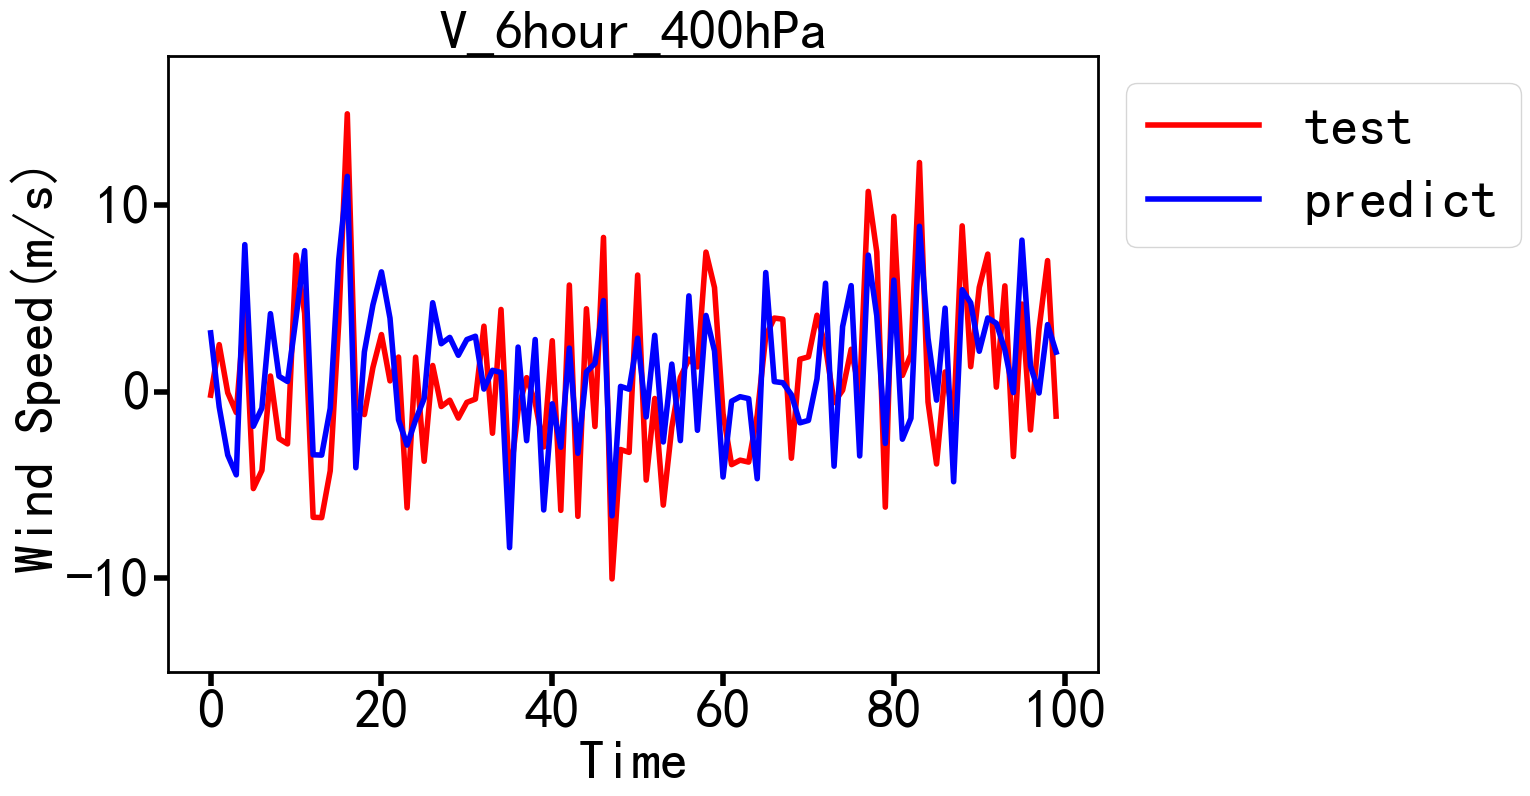

<Figure size 640x480 with 0 Axes>

In [253]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_v_0_0_avg_diff,predicty_v_0_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=18,selfvmin=-15,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='V_6hour_400hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

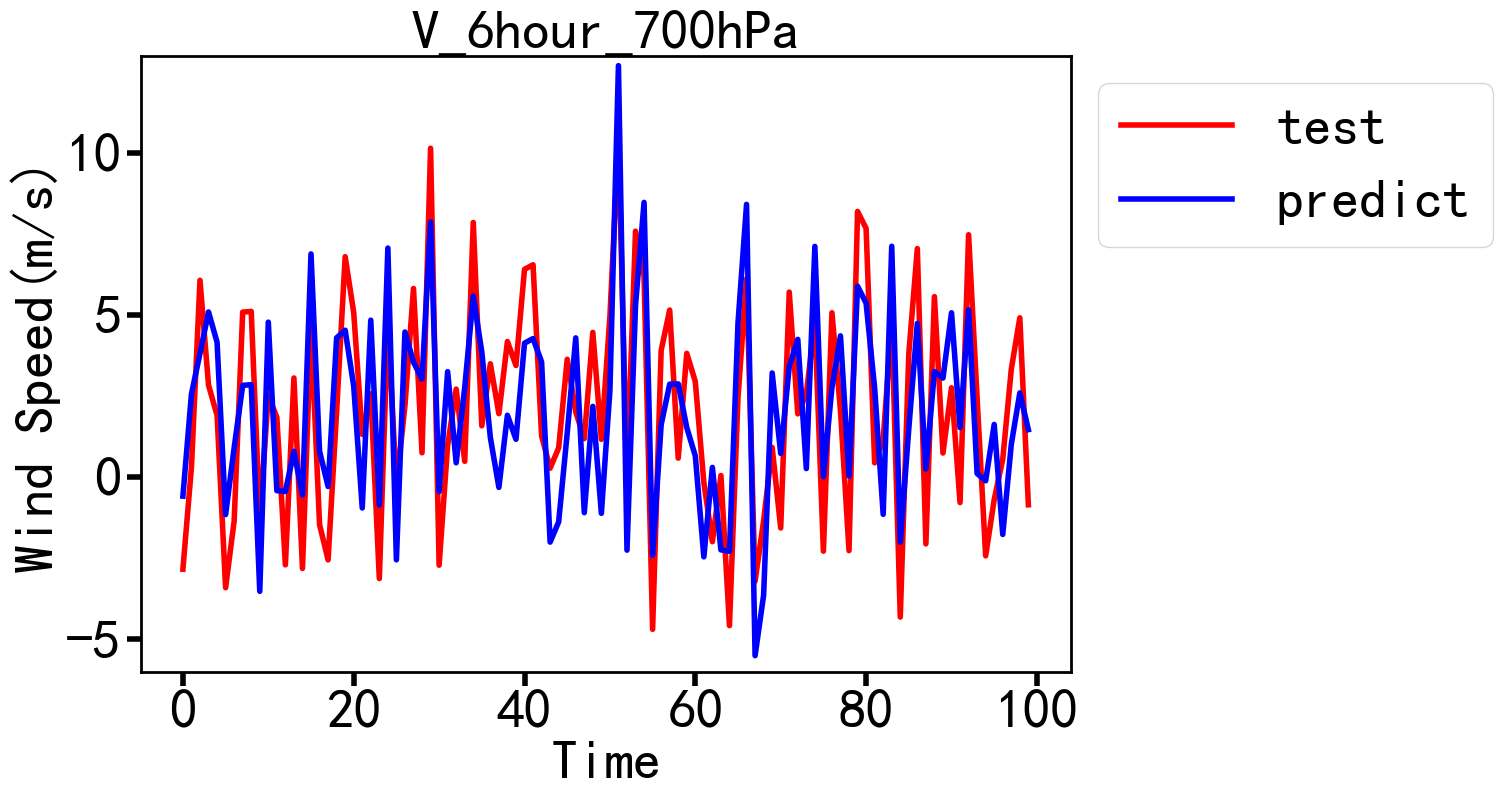

<Figure size 640x480 with 0 Axes>

In [226]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_v_4_0_avg_diff,predicty_v_4_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=0.08,selfvmin=0.04,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='V_6hour_700hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

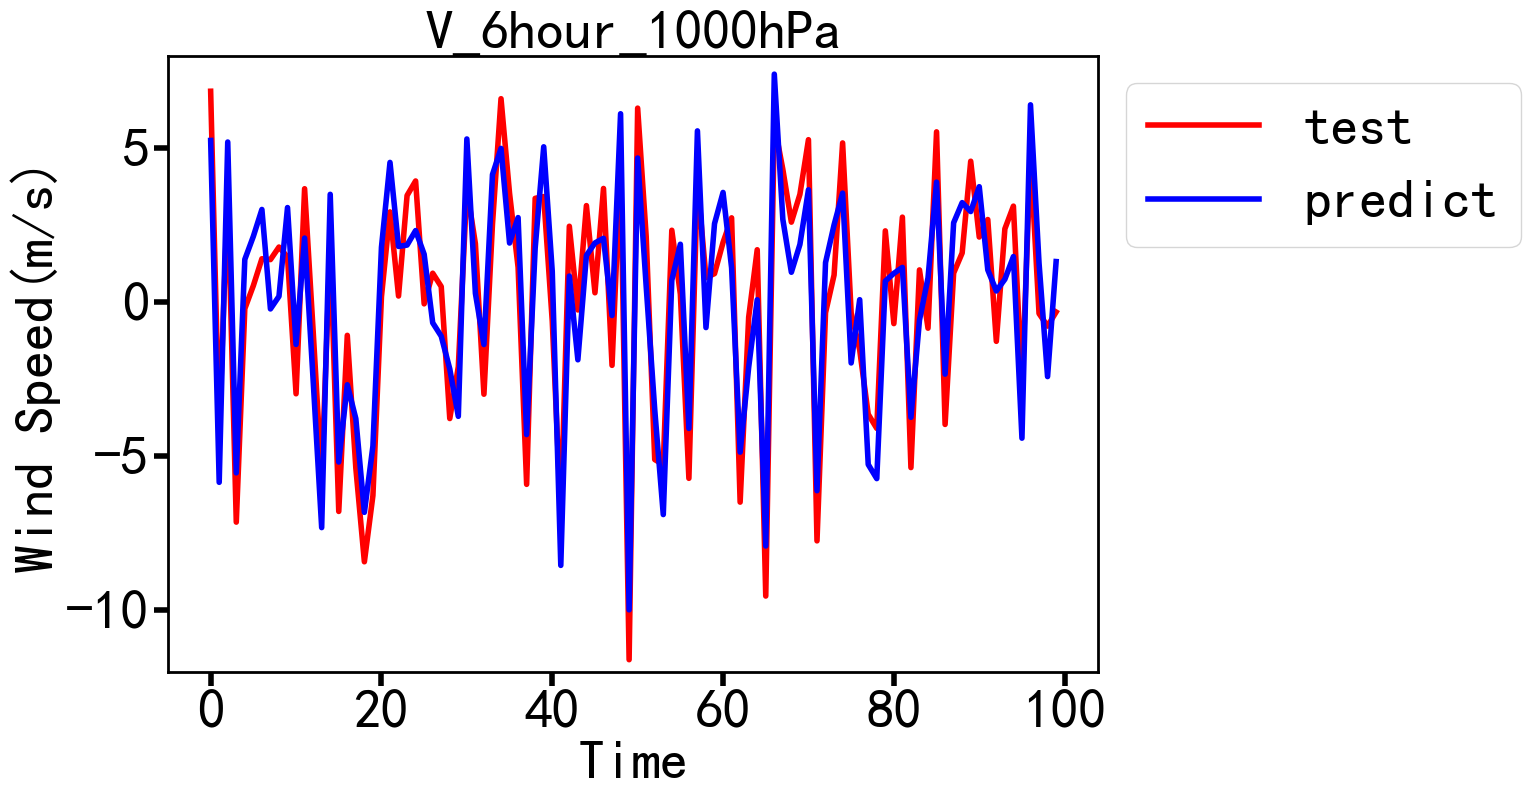

<Figure size 640x480 with 0 Axes>

In [227]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_v_6_0_avg_diff,predicty_v_6_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='no',selfvmax=0.08,selfvmin=0.04,linenum=2,xlabelname='Time',ylabelname='Wind Speed(m/s)',bar_line_title='V_6hour_1000hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

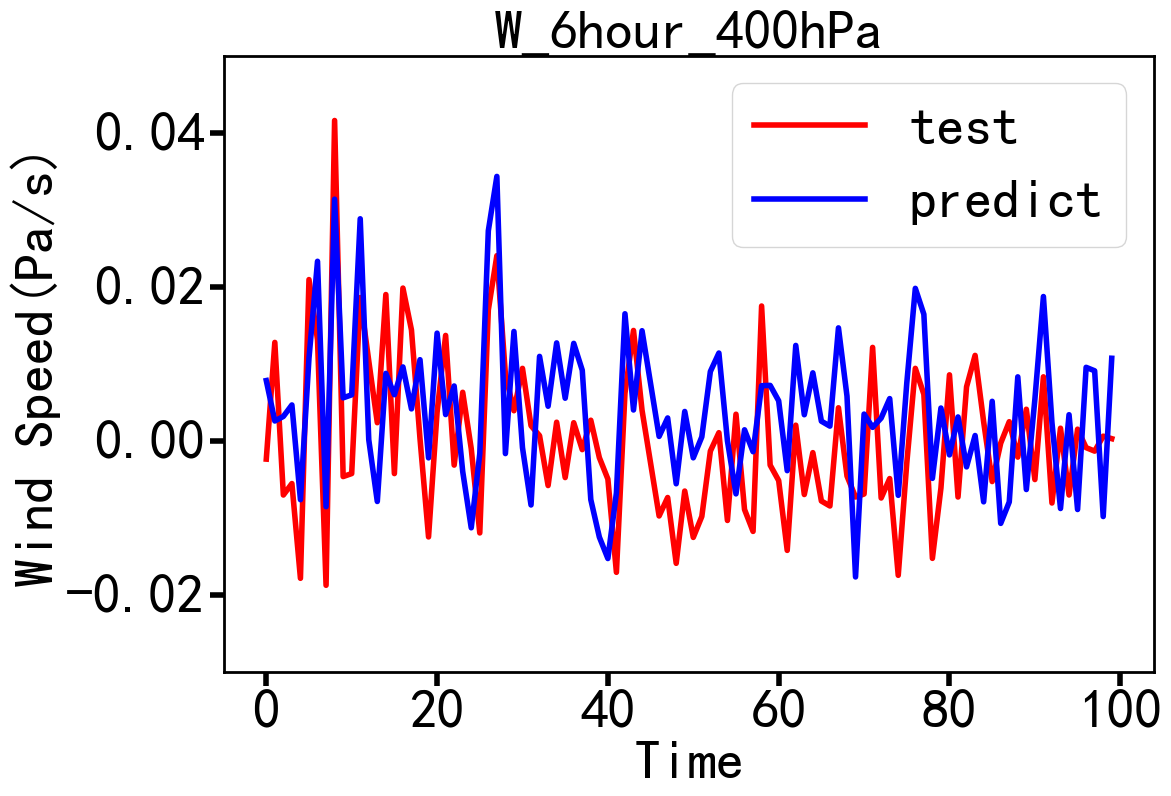

<Figure size 640x480 with 0 Axes>

In [246]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_w_0_0_avg_diff,predicty_w_0_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=0.05,selfvmin=-0.03,linenum=2,xlabelname='Time',ylabelname='Wind Speed(Pa/s)',bar_line_title='W_6hour_400hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

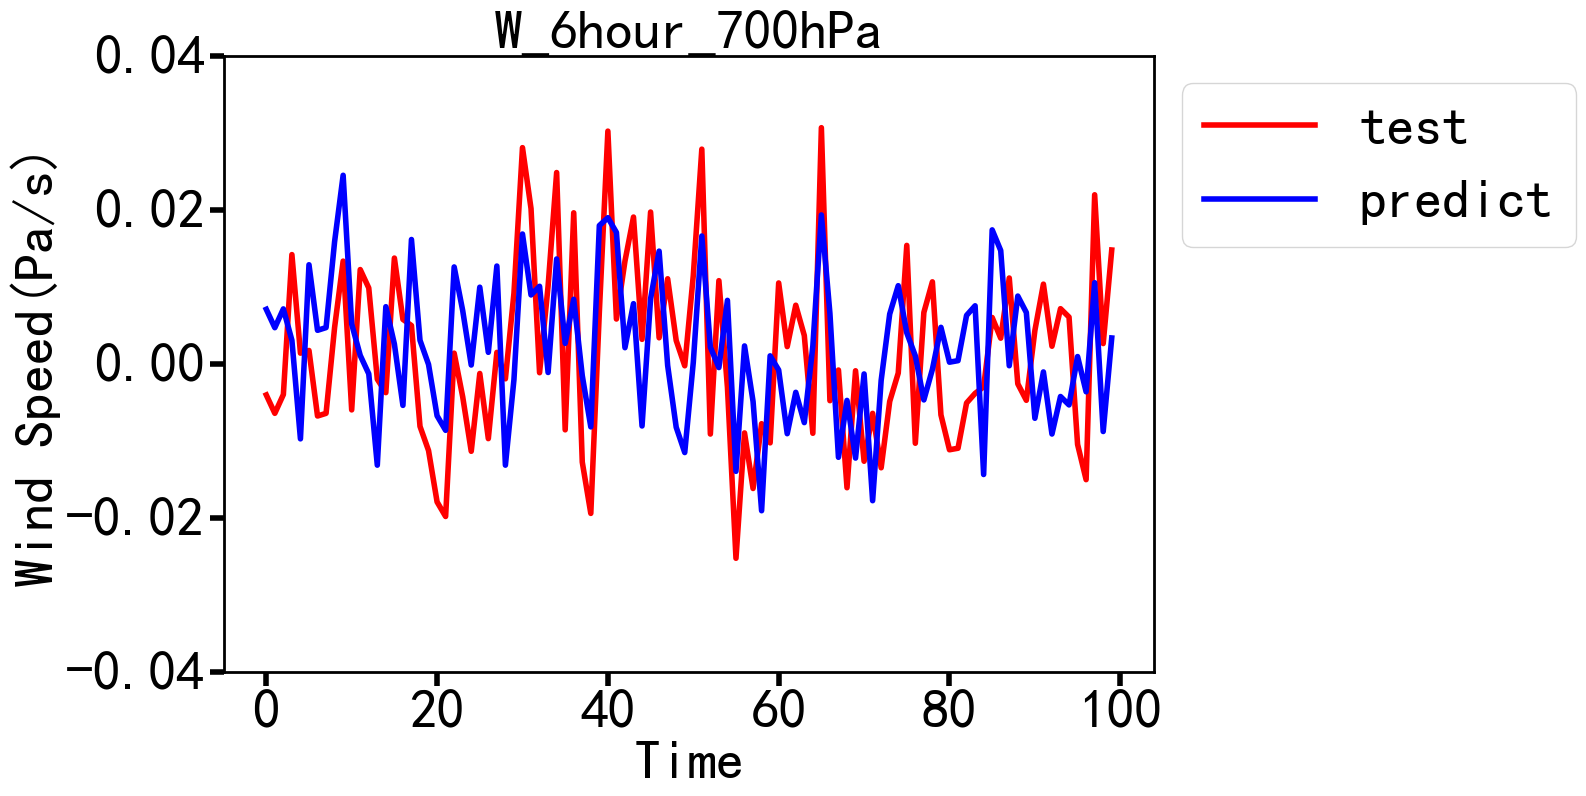

<Figure size 640x480 with 0 Axes>

In [244]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_w_4_0_avg_diff,predicty_w_4_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=0.04,selfvmin=-0.04,linenum=2,xlabelname='Time',ylabelname='Wind Speed(Pa/s)',bar_line_title='W_6hour_700hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')

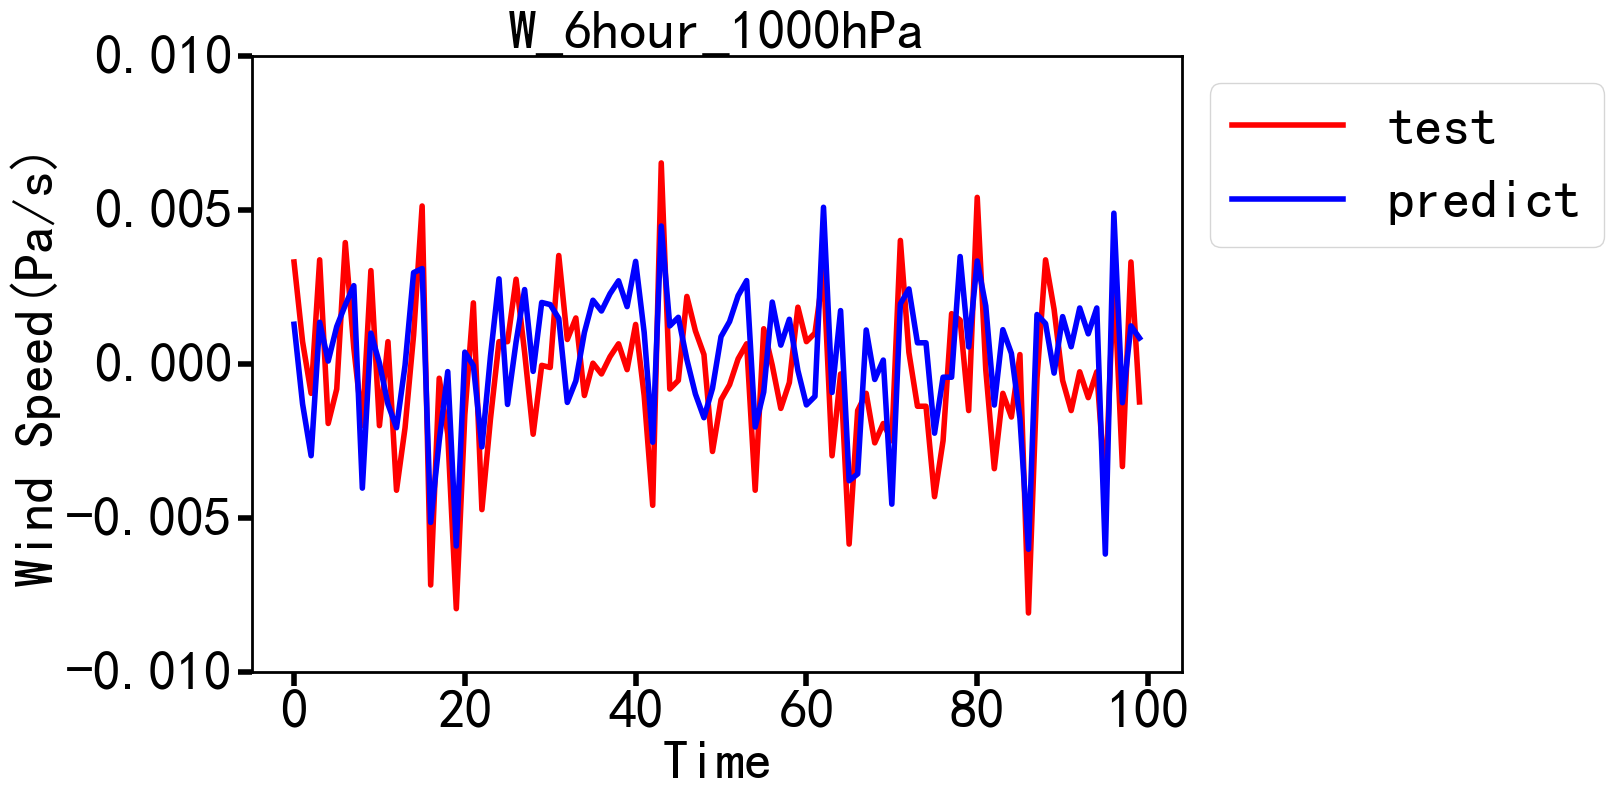

<Figure size 640x480 with 0 Axes>

In [249]:
import numpy as np
regressline,ym,yf,yd=Auto_paint_self.Autobar_or_line([testy_w_6_0_avg_diff,predicty_w_6_0_avg_diff],np.arange(100),'Time','no',None,None,'no',None,None,'no',None,None,'line',vs=None,ifself_vmax_vmin='yes',selfvmax=0.01,selfvmin=-0.01,linenum=2,xlabelname='Time',ylabelname='Wind Speed(Pa/s)',bar_line_title='W_6hour_1000hPa',label=['test','predict'],linewidth=4,selfcolor=['r','b'],iftend='no',ifmultitend='no',iffilter='no',filtermode=None,extent=None,rangement=None,ifdetend='no',detendtype=None,ifstdline='no',ifmean='no',xspace=20,labelsize=40,xlabelformat='self',valuemodel='+')